# Exploratory Data Analysis: Nero Dataset

**Цель:** Анализ данных для прогнозирования разворотов тренда на Forex (H1)

**Структура данных:**
- X ∈ R^{k×n×11} — входной тензор (k выборок, n фракталов, 11 признаков)
- signal ∈ {-1, 0, 1} — дискретная целевая переменная (экстремальный дисбаланс классов)
- predict ∈ R — непрерывная целевая метка (predict = -back * direction)
- ATR — Average True Range (показатель волатильности)
- 11 признаков фрактала: fractal_time, price, direction, front, back, strong, break, reverse, power, count, impulse

**Порядок столбцов:** time, signal, predict, ATR, fractal0, fractal1, ..., fractal{n-1}

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, shapiro, normaltest
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
from datetime import datetime
import re
import warnings
warnings.filterwarnings('ignore')

# Настройки визуализации
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Путь для сохранения графиков
PLOTS_DIR = 'plots/'

# Цвета для классов
CLASS_COLORS = {-1: '#e74c3c', 0: '#3498db', 1: '#2ecc71'}
CLASS_NAMES = {-1: 'Sell (-1)', 0: 'Neutral (0)', 1: 'Buy (1)'}

print("Библиотеки загружены успешно!")

Библиотеки загружены успешно!


## 1. Загрузка и парсинг данных

In [2]:
def parse_fractal_string(fractal_str: str) -> dict:
    """
    Парсинг строки фрактала в словарь признаков.
    
    Args:
        fractal_str: строка формата 'time:price:direction:front:back:strong:break:reverse:power:count:impulse'
    
    Returns:
        dict с 11 признаками или None при ошибке парсинга
    """
    parts = str(fractal_str).split(':')
    if len(parts) != 11:
        return None
    
    try:
        return {
            'fractal_time': int(parts[0]),
            'price': float(parts[1]),
            'direction': int(parts[2]),
            'front': float(parts[3]),
            'back': float(parts[4]),
            'strong': int(parts[5]),
            'break': int(parts[6]),
            'reverse': int(parts[7]),
            'power': float(parts[8]),
            'count': int(parts[9]),
            'impulse': float(parts[10])
        }
    except (ValueError, IndexError):
        return None


def load_nero_data(filepath: str) -> tuple:
    """
    Загрузка и парсинг данных Nero.
    
    Args:
        filepath: путь к CSV файлу
    
    Returns:
        tuple: (raw_df, fractal_0_df, fractal_cols, n_fractals, time_col)
    """
    print(f"Загрузка данных из {filepath}...")
    df = pd.read_csv(filepath, sep=';', low_memory=False)
    df.columns = df.columns.str.strip()
    
    print(f"Размер датасета: {df.shape}")
    print(f"Колонки: {list(df.columns[:5])}... (всего {len(df.columns)})")
    
    # Поддержка обоих вариантов имени временного столбца
    time_col = 'human_time' if 'human_time' in df.columns else 'time'
    print(f"Временной столбец: {time_col}")
    
    # Проверка обязательных столбцов
    required_cols = [time_col, 'signal', 'predict', 'ATR']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"⚠️ ВНИМАНИЕ: Отсутствуют столбцы: {missing}")
    else:
        print(f"✅ Все обязательные столбцы присутствуют: {required_cols}")
    
    # Динамическое определение фракталов через regex
    fractal_cols = sorted(
        [col for col in df.columns if re.match(r'^fractal\d+$', col)],
        key=lambda x: int(re.search(r'\d+', x).group())
    )
    n_fractals = len(fractal_cols)
    print(f"Найдено {n_fractals} фрактальных колонок")
    
    # Парсинг первого фрактала (fractal[0]) для всех строк
    first_fractal_col = fractal_cols[0]
    fractal_0_data = []
    
    for idx, row in df.iterrows():
        parsed = parse_fractal_string(row[first_fractal_col])
        if parsed:
            parsed['signal'] = row['signal']
            # Добавляем новые столбцы predict и ATR
            if 'predict' in df.columns:
                parsed['predict'] = row['predict']
            if 'ATR' in df.columns:
                parsed['ATR'] = row['ATR']
            parsed['row_idx'] = idx
            fractal_0_data.append(parsed)
    
    fractal_0_df = pd.DataFrame(fractal_0_data)
    print(f"Успешно распарсено {len(fractal_0_df)} строк fractal[0]")
    
    return df, fractal_0_df, fractal_cols, n_fractals, time_col

# Загрузка данных
raw_df, fractal_0_df, fractal_cols, n_fractals, time_col = load_nero_data('Nero_train_labeled.csv')

# Признаки фракталов
FEATURE_NAMES = ['fractal_time', 'price', 'direction', 'front', 'back', 
                 'strong', 'break', 'reverse', 'power', 'count', 'impulse']

print("\nПервые строки fractal[0]:")
fractal_0_df.head()

Загрузка данных из Nero_train_labeled.csv...


Размер датасета: (5082, 104)
Колонки: ['time', 'signal', 'predict', 'ATR', 'fractal0']... (всего 104)
Временной столбец: time
✅ Все обязательные столбцы присутствуют: ['time', 'signal', 'predict', 'ATR']
Найдено 100 фрактальных колонок


Успешно распарсено 5082 строк fractal[0]

Первые строки fractal[0]:


,fractal_time,price,direction,front,back,strong,break,reverse,power,count,impulse,signal,predict,ATR,row_idx
0,1690581600,0.333038,-1,1.606611,0.544376,0,0,1,9.591983,6,1.4,0,0.786233,3.8,0
1,1690765200,0.399689,1,0.786233,0.828315,0,0,0,10.189536,7,1.3,0,-2.532258,3.8,1
2,1690776000,0.287562,-1,2.127297,0.788865,0,0,1,0.515381,2,1.7,0,0.788865,3.8,2
3,1690790400,0.234954,-1,2.747866,1.062348,0,0,1,6.902567,5,1.8,0,1.062348,3.8,3
4,1690794000,0.325013,1,1.062348,1.033427,0,0,0,8.446112,6,2.1,0,-1.651365,3.8,4


## 1.1 Анализ целевой переменной predict

Столбец `predict` содержит непрерывные значения целевой метки, рассчитанные как `predict = -back * direction`.
- Положительные значения: сигнал Buy (direction=-1, впадина)
- Отрицательные значения: сигнал Sell (direction=1, пик)

АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ PREDICT

📊 Базовая статистика predict:
  Mean:   1.4525
  Median: -0.5442
  Std:    12.1202
  Min:    -112.6191
  Max:    181.5849
  Skew:   4.0407
  Kurt:   37.4082

📊 Статистика predict по классам signal:
             mean     median        std         min         max  count
signal                                                                
-1      36.210982  15.708465  38.757036    1.900858  110.986076     22
 0       1.352602  -0.548928  11.612539 -112.619080  181.584915   5044
 1     -14.843298  -5.464525  16.165089  -50.099194   -0.732916     16


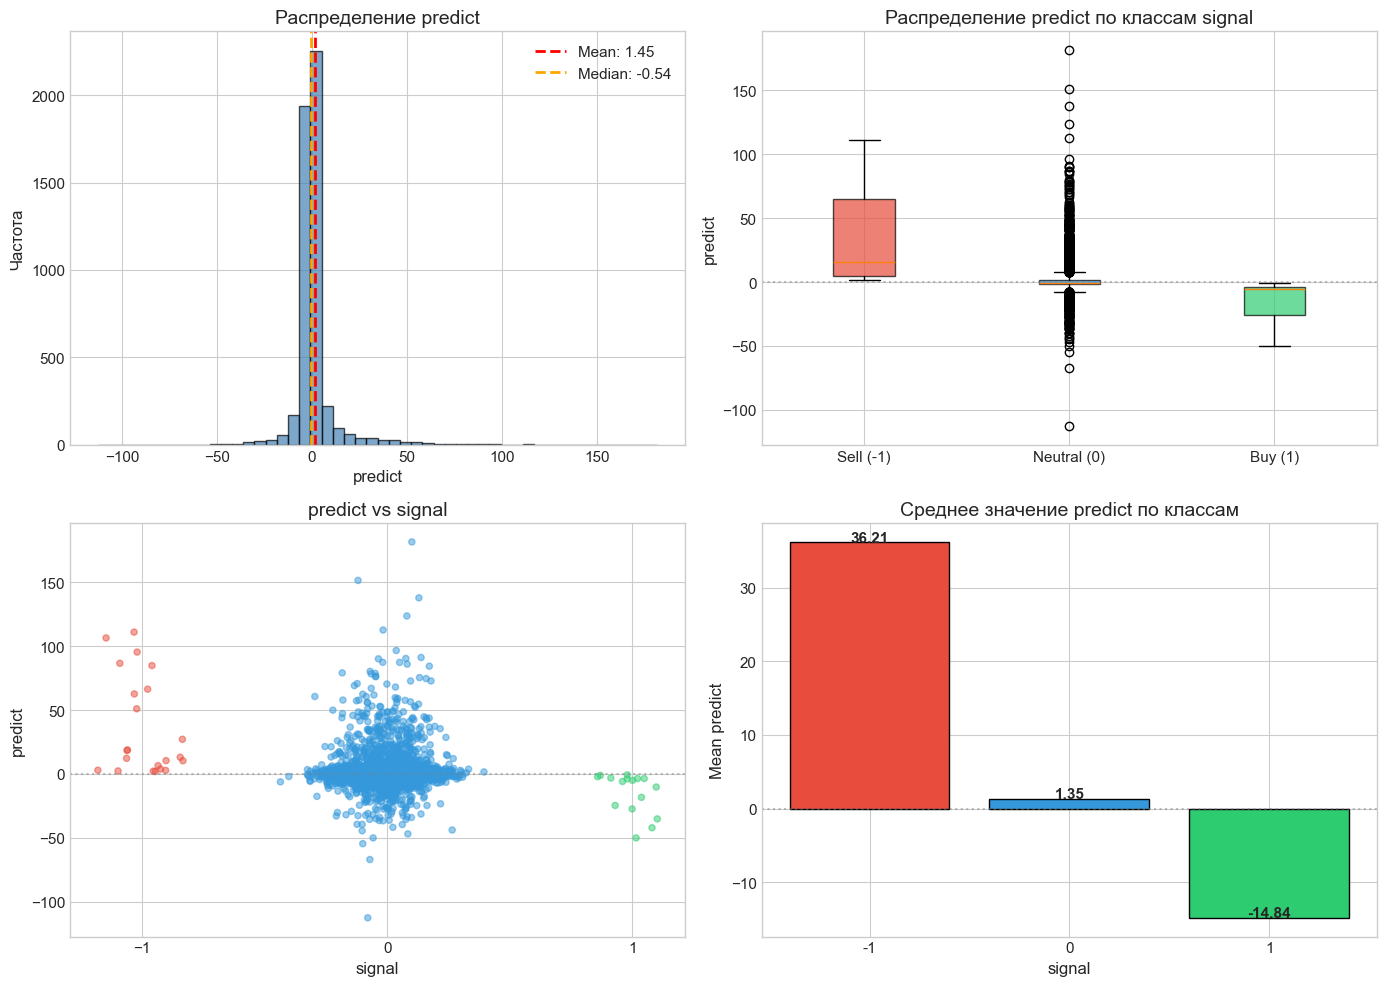


📈 Корреляция predict с signal: -0.1926


In [3]:
# Анализ столбца predict
if 'predict' in fractal_0_df.columns:
    print("=" * 80)
    print("АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ PREDICT")
    print("=" * 80)
    
    predict_values = fractal_0_df['predict']
    
    # Базовая статистика
    print("\n📊 Базовая статистика predict:")
    print(f"  Mean:   {predict_values.mean():.4f}")
    print(f"  Median: {predict_values.median():.4f}")
    print(f"  Std:    {predict_values.std():.4f}")
    print(f"  Min:    {predict_values.min():.4f}")
    print(f"  Max:    {predict_values.max():.4f}")
    print(f"  Skew:   {predict_values.skew():.4f}")
    print(f"  Kurt:   {predict_values.kurtosis():.4f}")
    
    # Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Гистограмма распределения
    axes[0, 0].hist(predict_values, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(predict_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {predict_values.mean():.2f}')
    axes[0, 0].axvline(predict_values.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {predict_values.median():.2f}')
    axes[0, 0].set_title('Распределение predict')
    axes[0, 0].set_xlabel('predict')
    axes[0, 0].set_ylabel('Частота')
    axes[0, 0].legend()
    
    # 2. Boxplot по классам signal (только для присутствующих классов)
    available_signals = sorted(fractal_0_df['signal'].unique())
    signal_groups = [fractal_0_df[fractal_0_df['signal'] == s]['predict'].values for s in available_signals]
    signal_labels = [CLASS_NAMES.get(s, f'Class {s}') for s in available_signals]
    signal_colors = [CLASS_COLORS.get(s, '#808080') for s in available_signals]
    
    bp = axes[0, 1].boxplot(signal_groups, labels=signal_labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], signal_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0, 1].set_title('Распределение predict по классам signal')
    axes[0, 1].set_ylabel('predict')
    axes[0, 1].axhline(0, color='gray', linestyle=':', alpha=0.5)
    
    # 3. Scatter: predict vs signal
    jitter = np.random.normal(0, 0.1, len(fractal_0_df))
    colors_scatter = [CLASS_COLORS.get(s, '#808080') for s in fractal_0_df['signal']]
    axes[1, 0].scatter(fractal_0_df['signal'] + jitter, predict_values, c=colors_scatter, alpha=0.5, s=20)
    axes[1, 0].set_title('predict vs signal')
    axes[1, 0].set_xlabel('signal')
    axes[1, 0].set_ylabel('predict')
    axes[1, 0].set_xticks(available_signals)
    axes[1, 0].axhline(0, color='gray', linestyle=':', alpha=0.5)
    
    # 4. Статистика по классам
    stats_by_class = fractal_0_df.groupby('signal')['predict'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    print("\n📊 Статистика predict по классам signal:")
    print(stats_by_class.to_string())
    
    # Визуализация средних значений
    means = stats_by_class['mean']
    bar_colors = [CLASS_COLORS.get(int(idx), '#808080') for idx in means.index]
    axes[1, 1].bar(means.index.astype(str), means.values, color=bar_colors, edgecolor='black')
    axes[1, 1].set_title('Среднее значение predict по классам')
    axes[1, 1].set_xlabel('signal')
    axes[1, 1].set_ylabel('Mean predict')
    axes[1, 1].axhline(0, color='gray', linestyle=':', alpha=0.5)
    for i, (idx, val) in enumerate(means.items()):
        axes[1, 1].text(i, val + 0.05, f'{val:.2f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}predict_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Корреляция predict с signal
    corr_predict_signal = fractal_0_df['predict'].corr(fractal_0_df['signal'])
    print(f"\n📈 Корреляция predict с signal: {corr_predict_signal:.4f}")
else:
    print("⚠️ Столбец 'predict' не найден в данных")

## 1.2 Анализ ATR (Average True Range)

ATR (Average True Range) — показатель волатильности рынка в момент формирования нового фрактала.
Высокие значения ATR указывают на повышенную волатильность.

АНАЛИЗ ATR (Average True Range)

📊 Базовая статистика ATR:
  Mean:   6.4086
  Median: 5.9000
  Std:    3.0283
  Min:    2.5000
  Max:    16.7000

📈 Корреляция ATR с признаками волатильности:
  ATR vs front: 0.0191
  ATR vs back: -0.0221
  ATR vs impulse: -0.0263


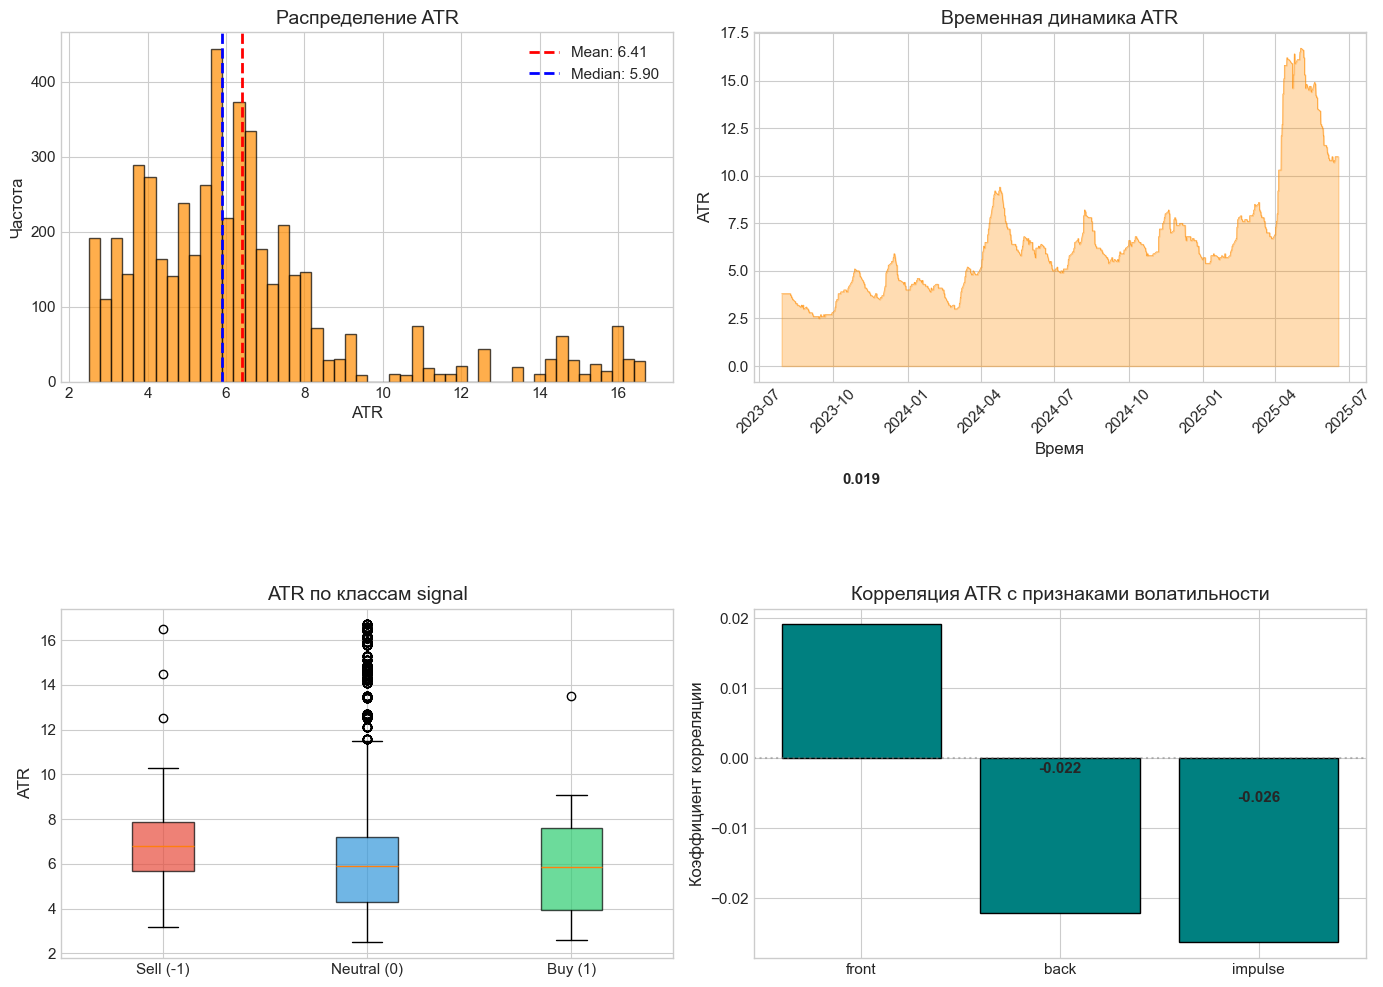


📊 Статистика ATR по классам signal:
            mean  median       std  min   max
signal                                       
-1      7.572727    6.80  3.287666  3.2  16.5
 0      6.404877    5.90  3.027236  2.5  16.7
 1      5.975000    5.85  2.849678  2.6  13.5


In [4]:
# Анализ столбца ATR
if 'ATR' in fractal_0_df.columns:
    print("=" * 80)
    print("АНАЛИЗ ATR (Average True Range)")
    print("=" * 80)
    
    atr_values = fractal_0_df['ATR']
    
    # Базовая статистика
    print("\n📊 Базовая статистика ATR:")
    print(f"  Mean:   {atr_values.mean():.4f}")
    print(f"  Median: {atr_values.median():.4f}")
    print(f"  Std:    {atr_values.std():.4f}")
    print(f"  Min:    {atr_values.min():.4f}")
    print(f"  Max:    {atr_values.max():.4f}")
    
    # Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Гистограмма распределения ATR
    axes[0, 0].hist(atr_values, bins=50, color='darkorange', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(atr_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {atr_values.mean():.2f}')
    axes[0, 0].axvline(atr_values.median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {atr_values.median():.2f}')
    axes[0, 0].set_title('Распределение ATR')
    axes[0, 0].set_xlabel('ATR')
    axes[0, 0].set_ylabel('Частота')
    axes[0, 0].legend()
    
    # 2. Временная динамика ATR
    if 'fractal_time' in fractal_0_df.columns:
        # Конвертируем timestamp в datetime
        fractal_0_df['datetime'] = pd.to_datetime(fractal_0_df['fractal_time'], unit='s')
        axes[0, 1].plot(fractal_0_df['datetime'], atr_values, color='darkorange', alpha=0.7, linewidth=0.5)
        axes[0, 1].fill_between(fractal_0_df['datetime'], atr_values, alpha=0.3, color='darkorange')
        axes[0, 1].set_title('Временная динамика ATR')
        axes[0, 1].set_xlabel('Время')
        axes[0, 1].set_ylabel('ATR')
        axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Boxplot ATR по классам signal
    # Boxplot ATR по классам (только для присутствующих классов)
    available_signals_atr = sorted(fractal_0_df['signal'].unique())
    signal_groups_atr = [fractal_0_df[fractal_0_df['signal'] == s]['ATR'].values for s in available_signals_atr]
    signal_labels_atr = [CLASS_NAMES.get(s, f'Class {s}') for s in available_signals_atr]
    signal_colors_atr = [CLASS_COLORS.get(s, '#808080') for s in available_signals_atr]
    
    bp = axes[1, 0].boxplot(signal_groups_atr, labels=signal_labels_atr, patch_artist=True)
    for patch, color in zip(bp['boxes'], signal_colors_atr):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1, 0].set_title('ATR по классам signal')
    axes[1, 0].set_ylabel('ATR')
    
    # 4. Корреляция ATR с признаками волатильности фракталов
    volatility_features = ['front', 'back', 'impulse']
    available_features = [f for f in volatility_features if f in fractal_0_df.columns]
    
    if available_features:
        correlations = {}
        for feature in available_features:
            corr = atr_values.corr(fractal_0_df[feature])
            correlations[feature] = corr
        
        bars = axes[1, 1].bar(correlations.keys(), correlations.values(), color='teal', edgecolor='black')
        axes[1, 1].set_title('Корреляция ATR с признаками волатильности')
        axes[1, 1].set_ylabel('Коэффициент корреляции')
        axes[1, 1].axhline(0, color='gray', linestyle=':', alpha=0.5)
        for bar, val in zip(bars, correlations.values()):
            axes[1, 1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')
        
        print("\n📈 Корреляция ATR с признаками волатильности:")
        for feature, corr in correlations.items():
            print(f"  ATR vs {feature}: {corr:.4f}")
    
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}atr_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Статистика ATR по классам
    atr_stats_by_class = fractal_0_df.groupby('signal')['ATR'].agg(['mean', 'median', 'std', 'min', 'max'])
    print("\n📊 Статистика ATR по классам signal:")
    print(atr_stats_by_class.to_string())
else:
    print("⚠️ Столбец 'ATR' не найден в данных")

Распределение классов:
  Класс -1:    22 (0.43%)
  Класс  0:  5044 (99.25%)
  Класс  1:    16 (0.31%)


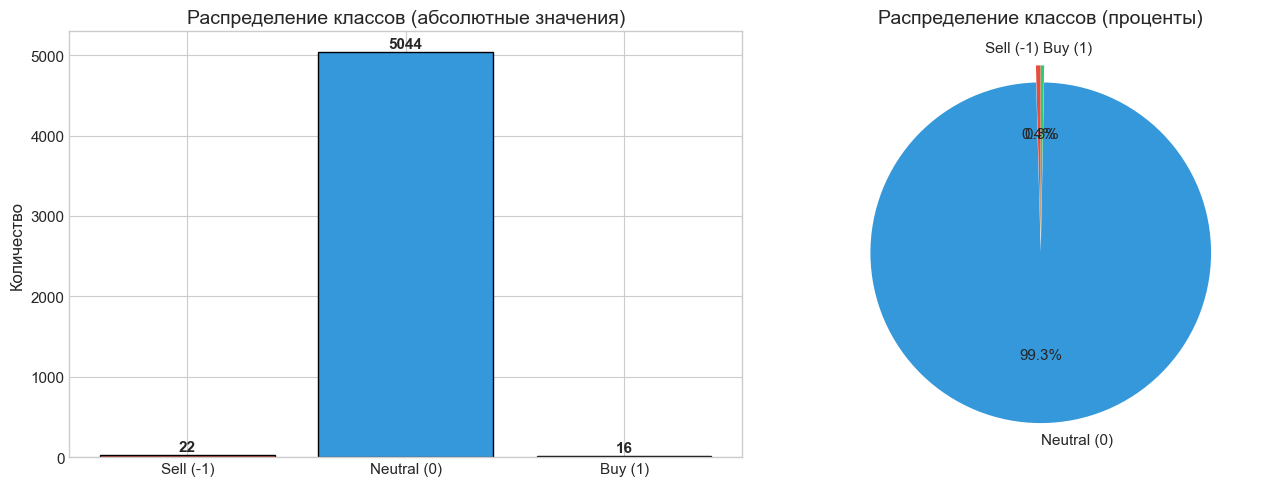


📊 Статистика классов:
   ⚠️ ВНИМАНИЕ: Экстремальный дисбаланс классов!
   Minority классы: -1 (n=22), +1 (n=16)
   Majority класс: 0 (n=5044, 99.3%)


In [5]:
# Распределение классов
class_dist = fractal_0_df['signal'].value_counts().sort_index()
print("Распределение классов:")
for cls, count in class_dist.items():
    pct = count / len(fractal_0_df) * 100
    print(f"  Класс {cls:2d}: {count:5d} ({pct:.2f}%)")

# Проверяем наличие всех классов
available_classes = sorted(class_dist.index.tolist())
n_classes = len(available_classes)

if n_classes == 0:
    print("⚠️ Нет данных для визуализации классов!")
else:
    # Визуализация распределения классов
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot
    colors = [CLASS_COLORS.get(c, '#808080') for c in class_dist.index]
    labels = [CLASS_NAMES.get(c, f'Class {c}') for c in class_dist.index]
    axes[0].bar(labels, class_dist.values, color=colors, edgecolor='black')
    axes[0].set_title('Распределение классов (абсолютные значения)')
    axes[0].set_ylabel('Количество')
    for i, (cls, count) in enumerate(class_dist.items()):
        axes[0].text(i, count + 50, str(count), ha='center', fontweight='bold')
    
    # Pie chart - динамический explode
    explode_values = [0.05] * n_classes
    axes[1].pie(class_dist.values, labels=labels, 
                colors=colors, autopct='%1.1f%%', startangle=90, explode=explode_values)
    axes[1].set_title('Распределение классов (проценты)')
    
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

# Статистика с проверкой наличия классов
print(f"\n📊 Статистика классов:")
if -1 in class_dist.index and 1 in class_dist.index:
    print(f"   ⚠️ ВНИМАНИЕ: Экстремальный дисбаланс классов!")
    print(f"   Minority классы: -1 (n={class_dist[-1]}), +1 (n={class_dist[1]})")
    print(f"   Majority класс: 0 (n={class_dist.get(0, 0)}, {class_dist.get(0, 0)/len(fractal_0_df)*100:.1f}%)")
elif n_classes == 1:
    print(f"   ⚠️ ВНИМАНИЕ: В данных только один класс ({available_classes[0]})!")
    print(f"   Это может быть связано с малым размером тестовых данных.")
else:
    print(f"   Присутствующие классы: {available_classes}")
    for cls in available_classes:
        print(f"   Класс {cls}: n={class_dist[cls]}, {class_dist[cls]/len(fractal_0_df)*100:.1f}%")

## 2. Статистический анализ признаков по классам

In [6]:
def compute_feature_stats_by_class(df: pd.DataFrame, features: list) -> pd.DataFrame:
    """
    Вычисление статистик для каждого признака по классам.
    
    Args:
        df: DataFrame с данными
        features: список признаков для анализа
    
    Returns:
        DataFrame со статистиками
    """
    stats_data = []
    available_signals = sorted(df['signal'].unique())
    
    for feature in features:
        for signal in available_signals:
            values = df[df['signal'] == signal][feature]
            
            stats_data.append({
                'feature': feature,
                'class': signal,
                'count': len(values),
                'mean': values.mean(),
                'std': values.std(),
                'min': values.min(),
                'q25': values.quantile(0.25),
                'median': values.quantile(0.50),
                'q75': values.quantile(0.75),
                'max': values.max()
            })
    
    return pd.DataFrame(stats_data)

# Исключаем fractal_time для статистического анализа признаков
analysis_features = [f for f in FEATURE_NAMES if f != 'fractal_time']

# Вычисление статистик
stats_df = compute_feature_stats_by_class(fractal_0_df, analysis_features)

# Форматированный вывод
print("=" * 100)
print("СТАТИСТИКА ПРИЗНАКОВ ПО КЛАССАМ (fractal[0])")
print("=" * 100)

for feature in analysis_features:
    print(f"\n📊 {feature.upper()}")
    print("-" * 80)
    feature_stats = stats_df[stats_df['feature'] == feature]
    display_df = feature_stats[['class', 'count', 'mean', 'std', 'min', 'q25', 'median', 'q75', 'max']].copy()
    display_df = display_df.round(4)
    print(display_df.to_string(index=False))

# Сохранение статистик
stats_df.to_csv(f'{PLOTS_DIR}feature_stats_by_class.csv', index=False)
print(f"\n✅ Статистики сохранены в {PLOTS_DIR}feature_stats_by_class.csv")

СТАТИСТИКА ПРИЗНАКОВ ПО КЛАССАМ (fractal[0])

📊 PRICE
--------------------------------------------------------------------------------
 class  count   mean    std   min    q25  median    q75    max
    -1     22 0.7867 0.1959 0.000 0.7634  0.8169 0.9137 0.9353
     0   5044 0.7963 0.2290 0.000 0.7556  0.8608 0.9539 1.0000
     1     16 0.7959 0.2416 0.249 0.7559  0.8724 0.9555 1.0000

📊 DIRECTION
--------------------------------------------------------------------------------
 class  count    mean    std  min  q25  median  q75  max
    -1     22 -1.0000 0.0000 -1.0 -1.0    -1.0 -1.0 -1.0
     0   5044  0.0488 0.9989 -1.0 -1.0     1.0  1.0  1.0
     1     16  1.0000 0.0000  1.0  1.0     1.0  1.0  1.0

📊 FRONT
--------------------------------------------------------------------------------
 class  count    mean     std    min    q25  median     q75      max
    -1     22 14.0204  6.6154 5.9701 9.6868 12.5131 17.5583  31.5214
     0   5044  6.1574 20.2474 0.1381 1.0599  1.7506  3.3374 191

### 2.1 Гистограммы распределений по классам

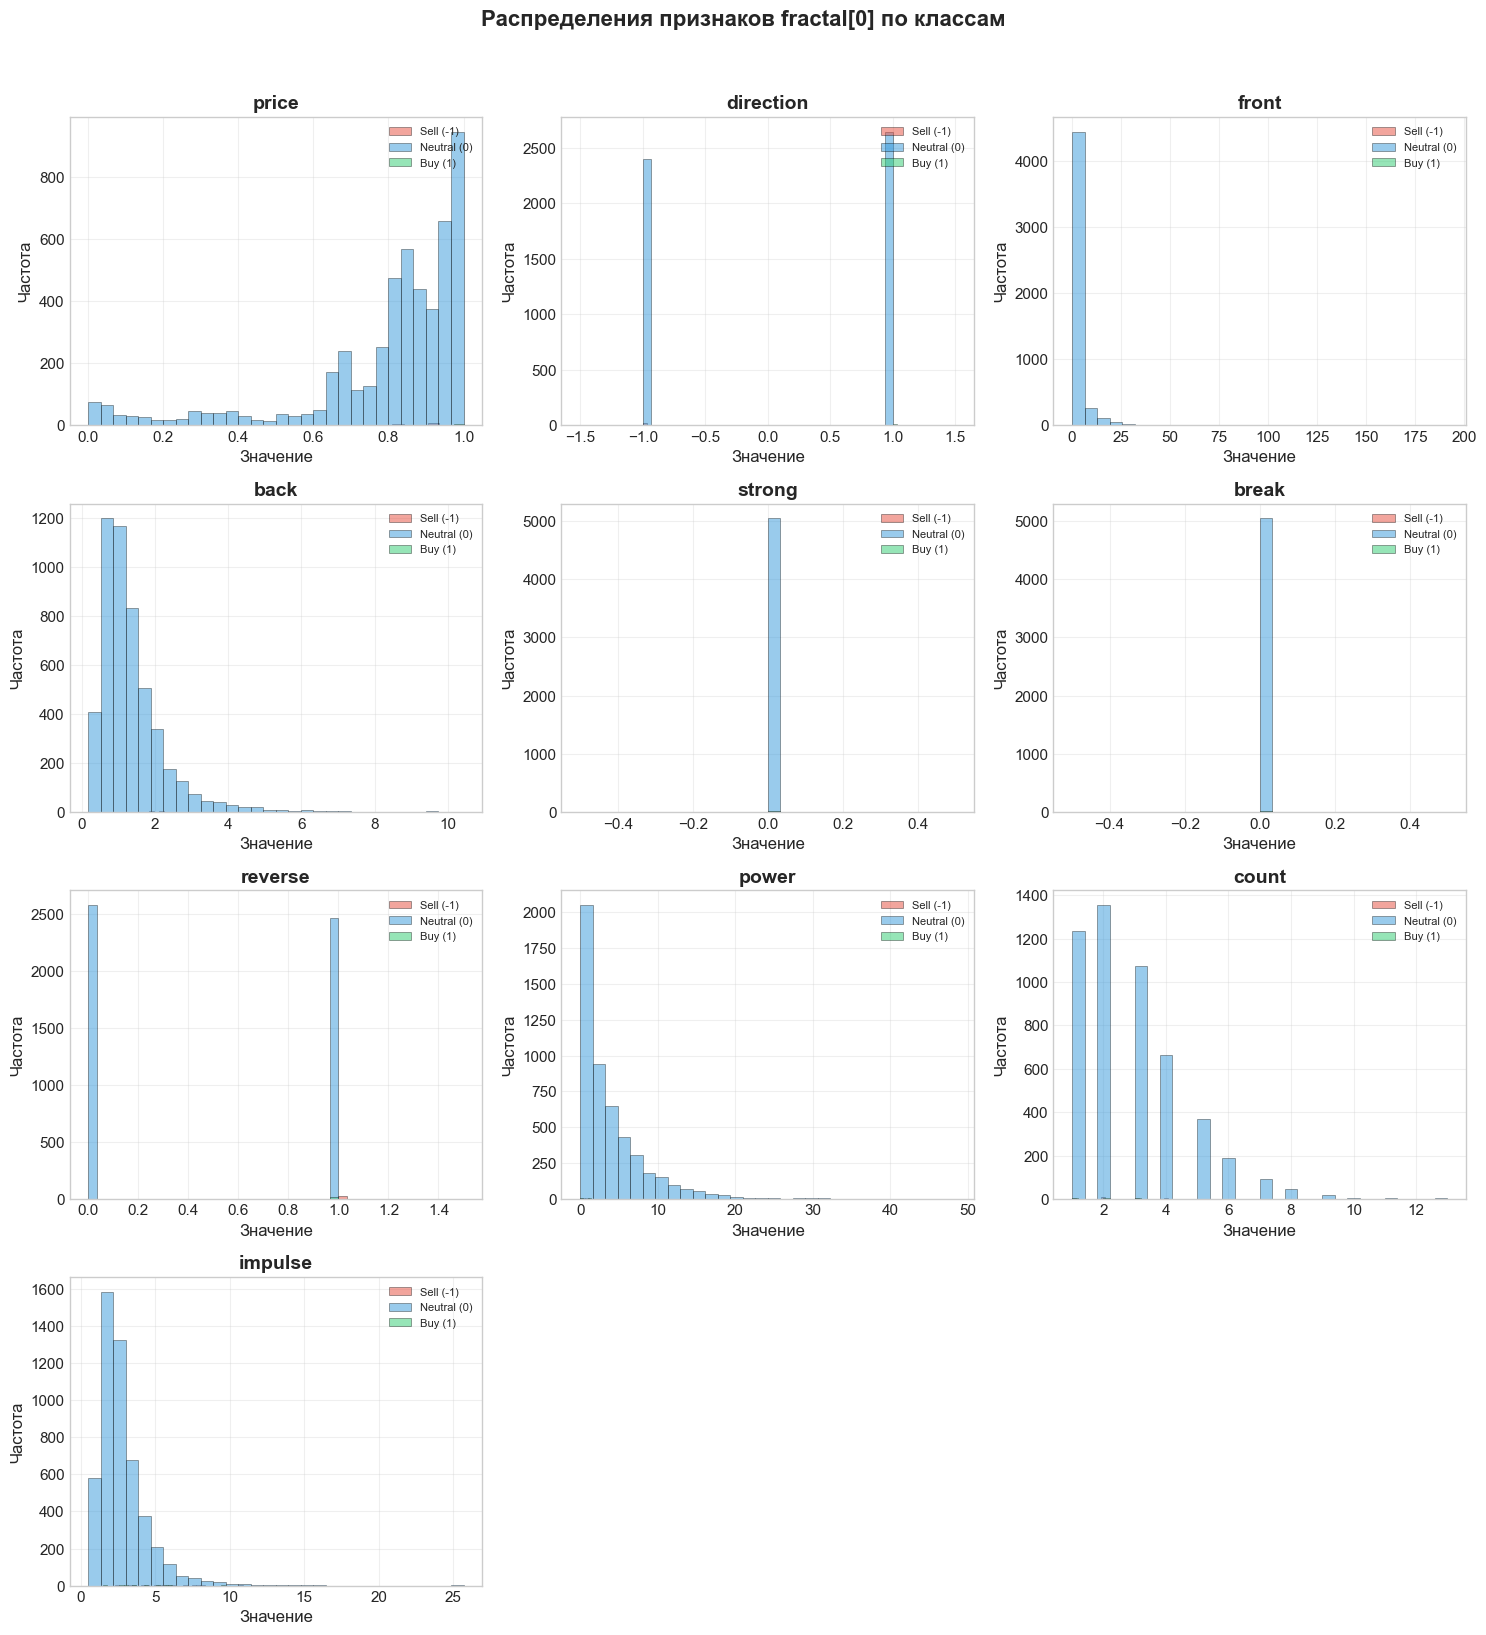

✅ Гистограммы сохранены в plots/histograms_by_class.png


In [7]:
def plot_histograms_by_class(df: pd.DataFrame, features: list, save_path: str):
    """
    Построение гистограмм для каждого признака с разбивкой по классам.
    """
    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten()
    
    available_signals = sorted(df['signal'].unique())
    
    for idx, feature in enumerate(features):
        ax = axes[idx]
        
        for signal in available_signals:
            values = df[df['signal'] == signal][feature]
            ax.hist(values, bins=30, alpha=0.5, label=CLASS_NAMES.get(signal, f'Class {signal}'), 
                    color=CLASS_COLORS.get(signal, '#808080'), edgecolor='black', linewidth=0.5)
        
        ax.set_title(feature, fontweight='bold')
        ax.set_xlabel('Значение')
        ax.set_ylabel('Частота')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Скрываем пустые axes
    for idx in range(len(features), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Распределения признаков fractal[0] по классам', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_histograms_by_class(fractal_0_df, analysis_features, f'{PLOTS_DIR}histograms_by_class.png')
print(f"✅ Гистограммы сохранены в {PLOTS_DIR}histograms_by_class.png")

### 2.2 Boxplots по классам

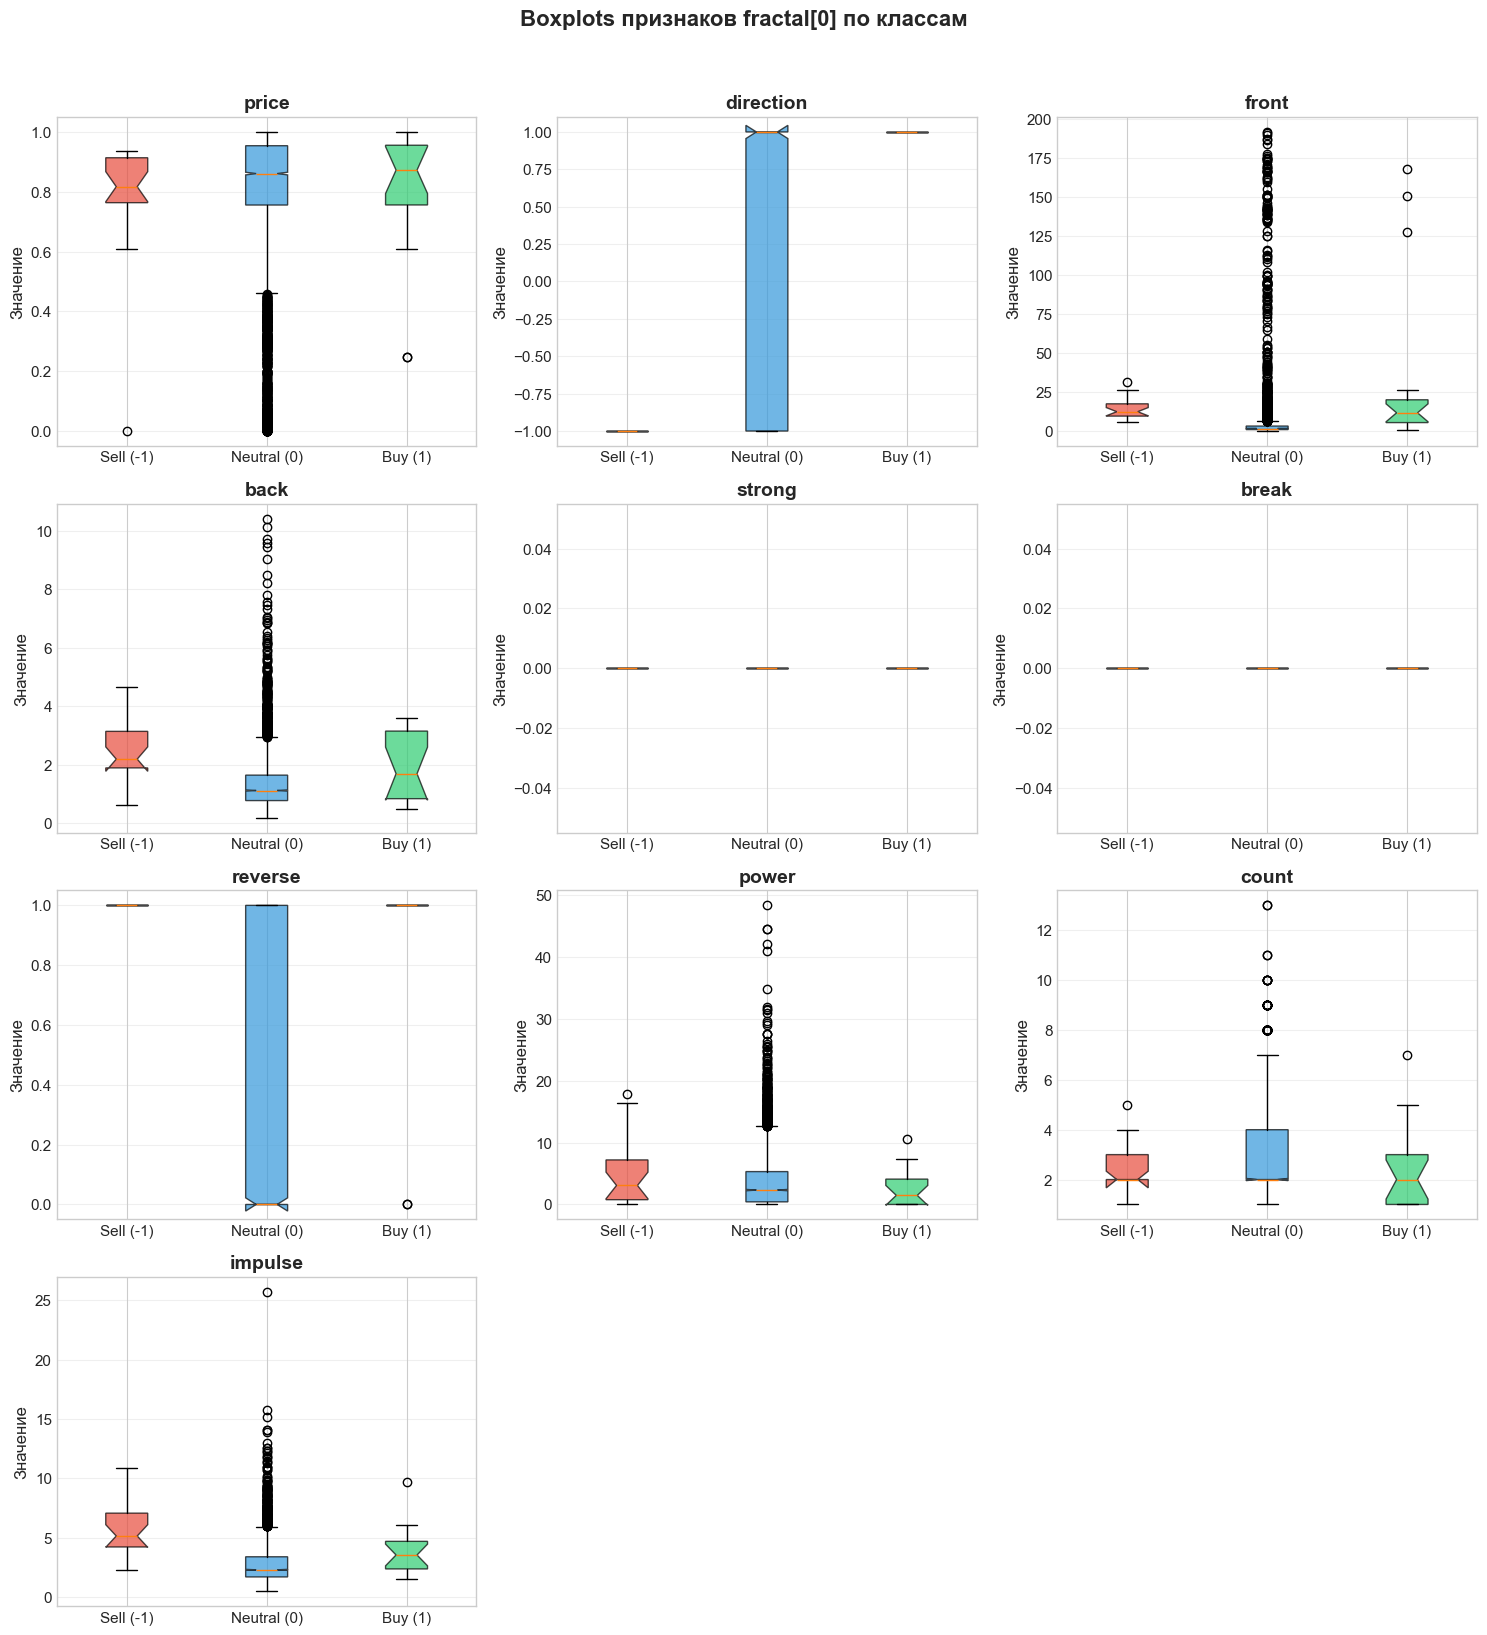

✅ Boxplots сохранены в plots/boxplots_by_class.png


In [8]:
def plot_boxplots_by_class(df: pd.DataFrame, features: list, save_path: str):
    """
    Построение boxplots для каждого признака с разбивкой по классам.
    """
    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten()
    
    for idx, feature in enumerate(features):
        ax = axes[idx]
        
        available_signals = sorted(df['signal'].unique())
        data_to_plot = [df[df['signal'] == s][feature] for s in available_signals]
        bp = ax.boxplot(data_to_plot, labels=[CLASS_NAMES.get(s, f'Class {s}') for s in available_signals], 
                        patch_artist=True, notch=True)
        
        for patch, signal in zip(bp['boxes'], available_signals):
            patch.set_facecolor(CLASS_COLORS.get(signal, '#808080'))
            patch.set_alpha(0.7)
        
        ax.set_title(feature, fontweight='bold')
        ax.set_ylabel('Значение')
        ax.grid(True, alpha=0.3, axis='y')
    
    # Скрываем пустые axes
    for idx in range(len(features), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Boxplots признаков fractal[0] по классам', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_boxplots_by_class(fractal_0_df, analysis_features, f'{PLOTS_DIR}boxplots_by_class.png')
print(f"✅ Boxplots сохранены в {PLOTS_DIR}boxplots_by_class.png")

## 3. Статистические тесты на различия между классами

In [9]:
def check_normality(values, alpha=0.05):
    """
    Проверка нормальности распределения.
    Использует тест Шапиро-Уилка для малых выборок (<5000)
    и D'Agostino-Pearson для больших.
    
    Returns:
        tuple: (is_normal: bool, p_value: float)
    """
    if len(values) < 3:
        return False, 0.0
    
    try:
        if len(values) < 5000:
            stat, p = shapiro(values[:min(len(values), 5000)])
        else:
            stat, p = normaltest(values)
        return p > alpha, p
    except:
        return False, 0.0


def cohens_d(group1, group2):
    """
    Вычисление размера эффекта Cohen's d.
    
    Интерпретация:
    - |d| < 0.2: незначительный эффект
    - 0.2 ≤ |d| < 0.5: малый эффект
    - 0.5 ≤ |d| < 0.8: средний эффект
    - |d| ≥ 0.8: большой эффект
    """
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    
    if pooled_std == 0:
        return 0.0
    
    return (group1.mean() - group2.mean()) / pooled_std


def interpret_cohens_d(d):
    """Интерпретация Cohen's d."""
    d_abs = abs(d)
    if d_abs < 0.2:
        return 'negligible'
    elif d_abs < 0.5:
        return 'small'
    elif d_abs < 0.8:
        return 'medium'
    else:
        return 'large'


def perform_statistical_tests(df: pd.DataFrame, features: list) -> pd.DataFrame:
    """
    Выполнение статистических тестов для сравнения классов.
    
    Сравнения:
    - Class -1 vs Class 0
    - Class 1 vs Class 0  
    - Class -1 vs Class 1
    """
    results = []
    comparisons = [(-1, 0), (1, 0), (-1, 1)]
    
    for feature in features:
        for c1, c2 in comparisons:
            g1 = df[df['signal'] == c1][feature].dropna()
            g2 = df[df['signal'] == c2][feature].dropna()
            
            if len(g1) < 3 or len(g2) < 3:
                continue
            
            # Проверка нормальности
            normal1, p_normal1 = check_normality(g1)
            normal2, p_normal2 = check_normality(g2)
            both_normal = normal1 and normal2
            
            # Выбор теста
            if both_normal:
                stat, p_value = ttest_ind(g1, g2, equal_var=False)  # Welch's t-test
                test_name = 't-test (Welch)'
            else:
                stat, p_value = mannwhitneyu(g1, g2, alternative='two-sided')
                test_name = 'Mann-Whitney U'
            
            # Effect size
            d = cohens_d(g1, g2)
            
            results.append({
                'feature': feature,
                'comparison': f'{c1} vs {c2}',
                'n_group1': len(g1),
                'n_group2': len(g2),
                'test': test_name,
                'statistic': stat,
                'p_value': p_value,
                'significant_005': p_value < 0.05,
                'significant_001': p_value < 0.01,
                'cohens_d': d,
                'effect_size': interpret_cohens_d(d),
                'mean_diff': g1.mean() - g2.mean()
            })
    
    return pd.DataFrame(results)

# Выполнение тестов
test_results = perform_statistical_tests(fractal_0_df, analysis_features)

print("=" * 120)
print("РЕЗУЛЬТАТЫ СТАТИСТИЧЕСКИХ ТЕСТОВ")
print("=" * 120)
print("\n⚠️ ВАЖНО: При малых размерах minority классов (n=240, n=257) тесты имеют низкую мощность.")
print("   Cohen's d (effect size) более информативен, чем p-value!\n")

# Форматированный вывод
display_cols = ['feature', 'comparison', 'test', 'p_value', 'significant_005', 'cohens_d', 'effect_size']
display_df = test_results[display_cols].copy()
display_df['p_value'] = display_df['p_value'].apply(lambda x: f'{x:.2e}' if x < 0.001 else f'{x:.4f}')
display_df['cohens_d'] = display_df['cohens_d'].round(3)

print(display_df.to_string(index=False))

# Сохранение результатов
test_results.to_csv(f'{PLOTS_DIR}statistical_tests.csv', index=False)
print(f"\n✅ Результаты тестов сохранены в {PLOTS_DIR}statistical_tests.csv")

РЕЗУЛЬТАТЫ СТАТИСТИЧЕСКИХ ТЕСТОВ

⚠️ ВАЖНО: При малых размерах minority классов (n=240, n=257) тесты имеют низкую мощность.
   Cohen's d (effect size) более информативен, чем p-value!

  feature comparison           test  p_value  significant_005  cohens_d effect_size
    price    -1 vs 0 Mann-Whitney U   0.1194            False    -0.042  negligible
    price     1 vs 0 Mann-Whitney U   0.6715            False    -0.002  negligible
    price    -1 vs 1 Mann-Whitney U   0.2938            False    -0.042  negligible
direction    -1 vs 0 Mann-Whitney U 8.98e-07             True    -1.052       large
direction     1 vs 0 Mann-Whitney U 1.43e-04             True     0.954       large
direction    -1 vs 1 t-test (Welch) 0.00e+00             True     0.000  negligible
    front    -1 vs 0 Mann-Whitney U 3.58e-12             True     0.389       small
    front     1 vs 0 Mann-Whitney U 3.50e-05             True     1.461       large
    front    -1 vs 1 Mann-Whitney U   0.7338            Fal

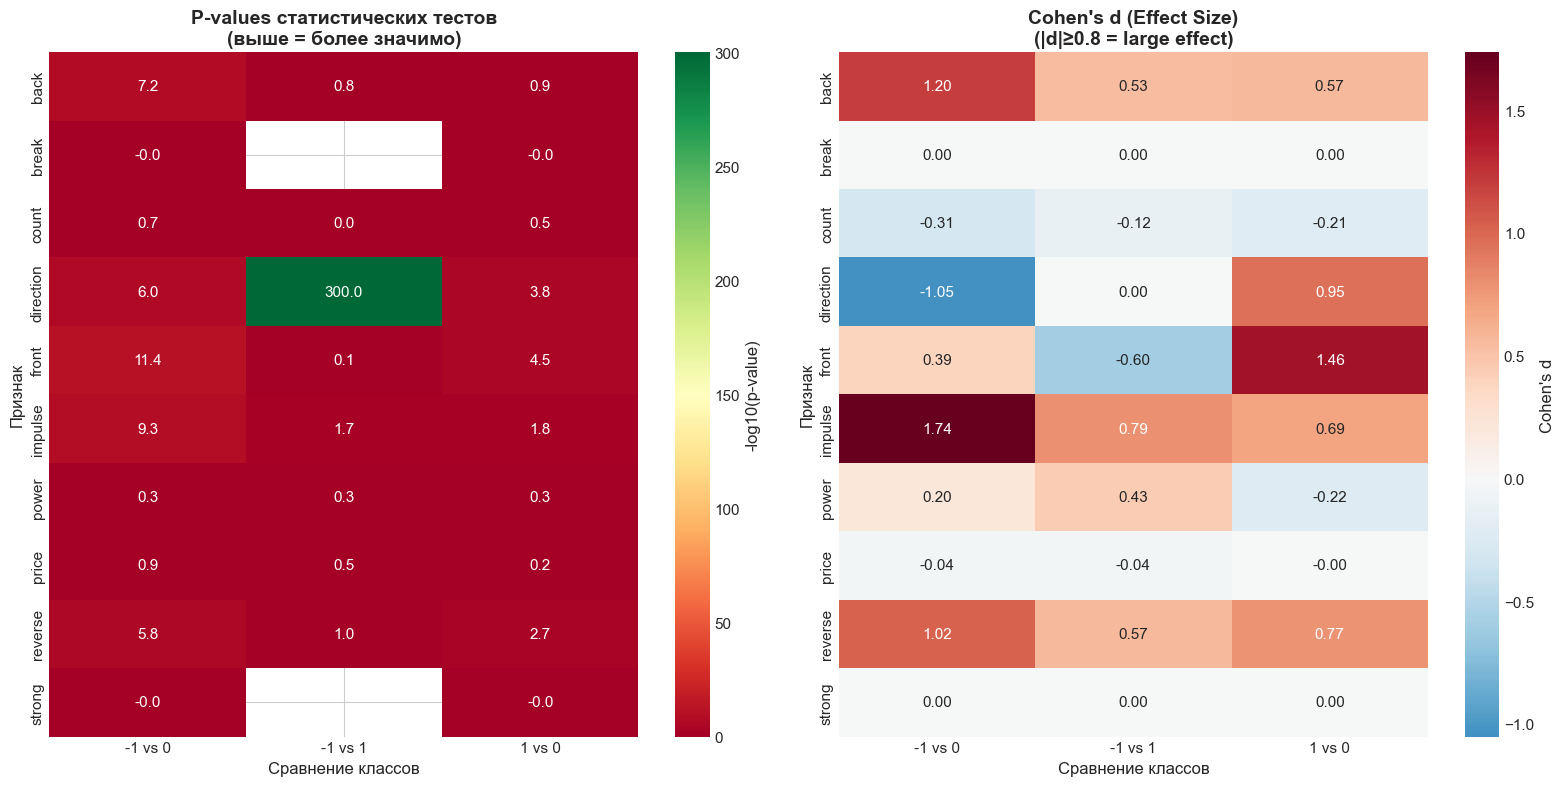

✅ Heatmap сохранён в plots/statistical_tests_heatmap.png


In [10]:
# Визуализация p-values и effect sizes
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Pivot для heatmap p-values
pivot_pvalue = test_results.pivot(index='feature', columns='comparison', values='p_value')

# Heatmap p-values (log scale)
log_pvalues = -np.log10(pivot_pvalue + 1e-300)  # Избегаем log(0)
sns.heatmap(log_pvalues, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0],
            cbar_kws={'label': '-log10(p-value)'})
axes[0].set_title('P-values статистических тестов\n(выше = более значимо)', fontweight='bold')
axes[0].set_xlabel('Сравнение классов')
axes[0].set_ylabel('Признак')

# Pivot для heatmap Cohen's d
pivot_cohens = test_results.pivot(index='feature', columns='comparison', values='cohens_d')

# Heatmap Cohen's d
sns.heatmap(pivot_cohens, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1],
            cbar_kws={'label': "Cohen's d"})
axes[1].set_title("Cohen's d (Effect Size)\n(|d|≥0.8 = large effect)", fontweight='bold')
axes[1].set_xlabel('Сравнение классов')
axes[1].set_ylabel('Признак')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}statistical_tests_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Heatmap сохранён в {PLOTS_DIR}statistical_tests_heatmap.png")

In [11]:
# Анализ наиболее значимых различий
print("\n" + "=" * 80)
print("НАИБОЛЕЕ ЗНАЧИМЫЕ РАЗЛИЧИЯ (|Cohen's d| ≥ 0.5)")
print("=" * 80)

significant_effects = test_results[test_results['cohens_d'].abs() >= 0.5].sort_values('cohens_d', key=abs, ascending=False)

if len(significant_effects) > 0:
    for _, row in significant_effects.iterrows():
        print(f"\n📌 {row['feature']} ({row['comparison']})")
        print(f"   Cohen's d = {row['cohens_d']:.3f} ({row['effect_size']} effect)")
        print(f"   p-value = {row['p_value']:.2e}")
        print(f"   Mean difference = {row['mean_diff']:.4f}")
else:
    print("\nНе найдено признаков со средним или большим размером эффекта.")


НАИБОЛЕЕ ЗНАЧИМЫЕ РАЗЛИЧИЯ (|Cohen's d| ≥ 0.5)

📌 impulse (-1 vs 0)
   Cohen's d = 1.736 (large effect)
   p-value = 5.28e-10
   Mean difference = 2.8220

📌 front (1 vs 0)
   Cohen's d = 1.461 (large effect)
   p-value = 3.50e-05
   Mean difference = 29.8739

📌 back (-1 vs 0)
   Cohen's d = 1.196 (large effect)
   p-value = 6.51e-08
   Mean difference = 1.1210

📌 direction (-1 vs 0)
   Cohen's d = -1.052 (large effect)
   p-value = 8.98e-07
   Mean difference = -1.0488

📌 reverse (-1 vs 0)
   Cohen's d = 1.024 (large effect)
   p-value = 1.72e-06
   Mean difference = 0.5111

📌 direction (1 vs 0)
   Cohen's d = 0.954 (large effect)
   p-value = 1.43e-04
   Mean difference = 0.9512

📌 impulse (-1 vs 1)
   Cohen's d = 0.794 (medium effect)
   p-value = 2.17e-02
   Mean difference = 1.6989

📌 reverse (1 vs 0)
   Cohen's d = 0.773 (medium effect)
   p-value = 2.04e-03
   Mean difference = 0.3861

📌 impulse (1 vs 0)
   Cohen's d = 0.691 (medium effect)
   p-value = 1.59e-02
   Mean differen

## 4. Корреляционный анализ

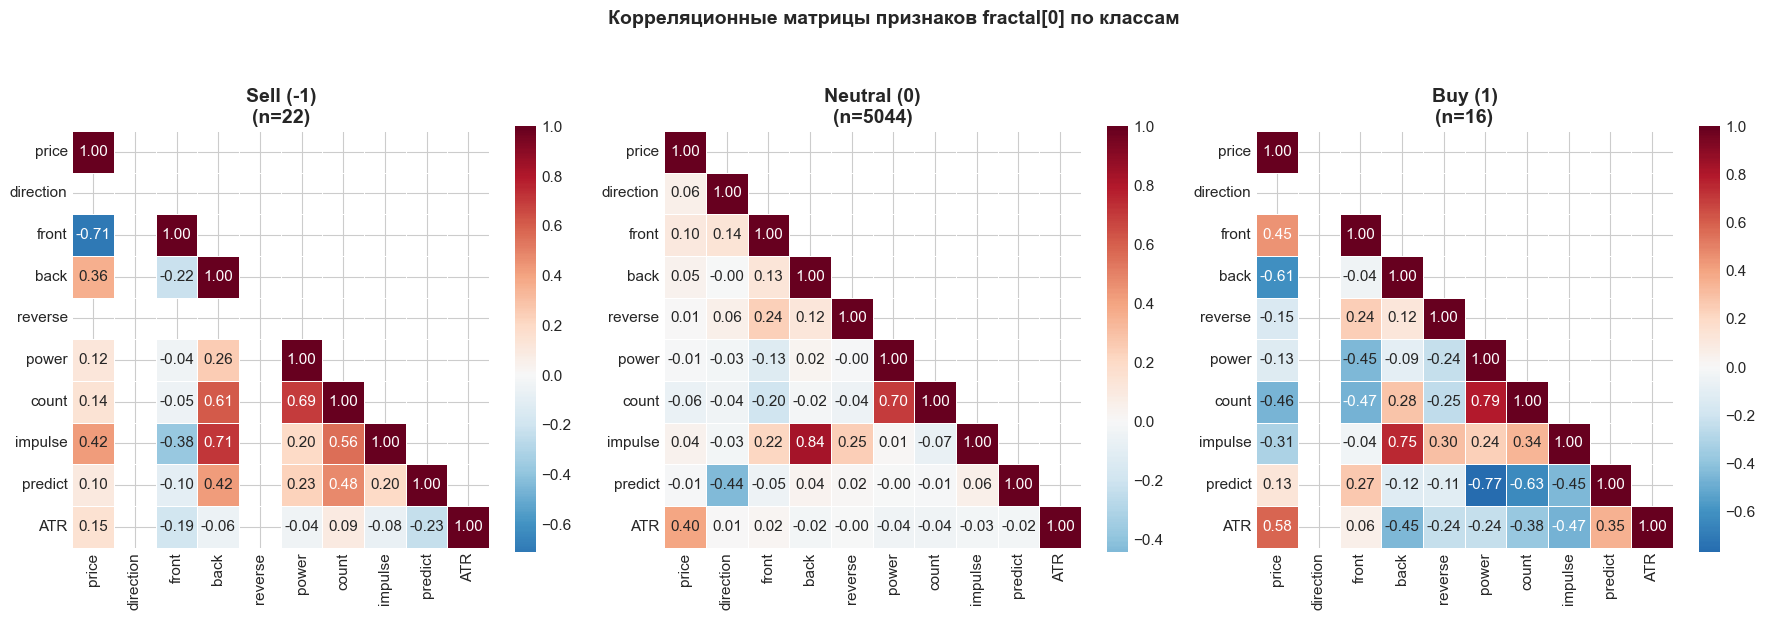

✅ Корреляционные матрицы сохранены в plots/correlation_matrices_by_class.png


In [12]:
# Корреляционные матрицы для каждого класса

# Добавляем predict и ATR к анализируемым признакам, если они есть
corr_features = [f for f in analysis_features if f not in ['strong', 'break']]  # Исключаем константные
if 'predict' in fractal_0_df.columns:
    corr_features.append('predict')
if 'ATR' in fractal_0_df.columns:
    corr_features.append('ATR')

available_signals_corr = sorted(fractal_0_df['signal'].unique())
n_classes_corr = len(available_signals_corr)
fig, axes = plt.subplots(1, max(n_classes_corr, 1), figsize=(6*max(n_classes_corr, 1), 6))
if n_classes_corr == 1:
    axes = [axes]  # Ensure axes is iterable

for idx, signal in enumerate(available_signals_corr):
    class_data = fractal_0_df[fractal_0_df['signal'] == signal][corr_features]
    corr_matrix = class_data.corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, ax=axes[idx], square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{CLASS_NAMES.get(signal, f"Class {signal}")}\n(n={len(class_data)})', fontweight='bold')

plt.suptitle('Корреляционные матрицы признаков fractal[0] по классам', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}correlation_matrices_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Корреляционные матрицы сохранены в {PLOTS_DIR}correlation_matrices_by_class.png")

Парсинг первых 5 фракталов для анализа корреляций...


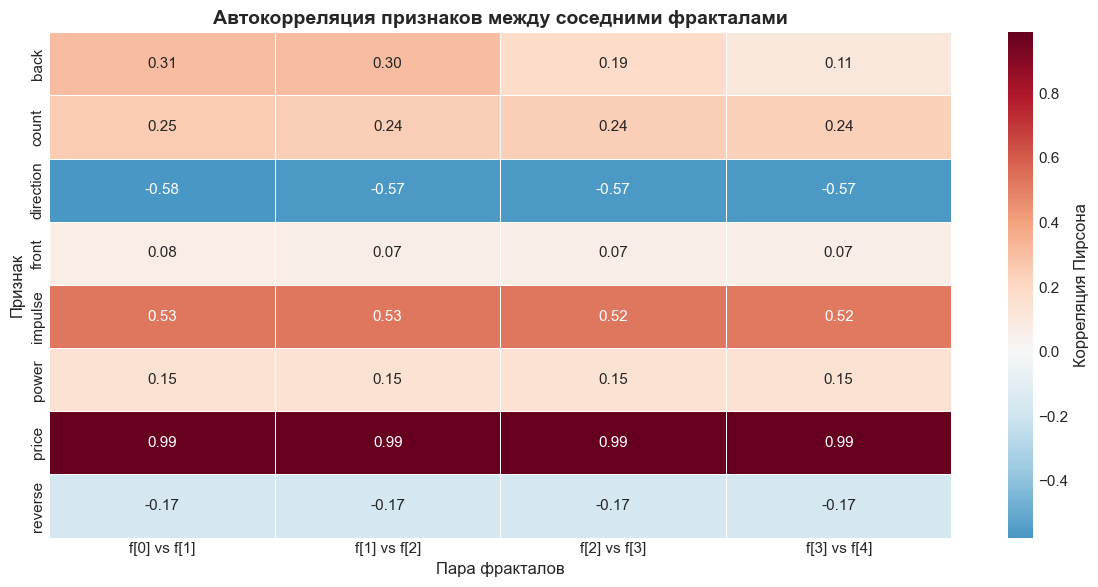

✅ Кросс-фрактальные корреляции сохранены в plots/cross_fractal_correlation.png


In [13]:
# Корреляция признаков между соседними фракталами
def parse_multiple_fractals(df: pd.DataFrame, fractal_cols: list, max_fractals: int = 10) -> dict:
    """
    Парсинг нескольких фракталов для анализа корреляций между ними.
    """
    fractals_data = {i: [] for i in range(max_fractals)}
    
    for idx, row in df.iterrows():
        for f_idx in range(min(max_fractals, len(fractal_cols))):
            parsed = parse_fractal_string(row[fractal_cols[f_idx]])
            if parsed:
                parsed['row_idx'] = idx
                parsed['signal'] = row['signal']
                fractals_data[f_idx].append(parsed)
    
    return {i: pd.DataFrame(data) for i, data in fractals_data.items()}

print("Парсинг первых 5 фракталов для анализа корреляций...")
fractals_dict = parse_multiple_fractals(raw_df, fractal_cols, max_fractals=5)

# Корреляция между fractal[0] и fractal[1] для каждого признака
cross_fractal_corr = []
for feature in analysis_features:
    if feature in ['strong', 'break']:  # Пропускаем константные
        continue
    for i in range(4):
        if i not in fractals_dict or (i+1) not in fractals_dict:
            continue
        
        f1 = fractals_dict[i][feature]
        f2 = fractals_dict[i+1][feature]
        
        # Выравниваем по длине
        min_len = min(len(f1), len(f2))
        corr = np.corrcoef(f1[:min_len], f2[:min_len])[0, 1]
        
        cross_fractal_corr.append({
            'feature': feature,
            'fractal_pair': f'f[{i}] vs f[{i+1}]',
            'correlation': corr
        })

cross_corr_df = pd.DataFrame(cross_fractal_corr)

# Визуализация
fig, ax = plt.subplots(figsize=(12, 6))

pivot_cross = cross_corr_df.pivot(index='feature', columns='fractal_pair', values='correlation')
sns.heatmap(pivot_cross, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Корреляция Пирсона'})
ax.set_title('Автокорреляция признаков между соседними фракталами', fontweight='bold')
ax.set_xlabel('Пара фракталов')
ax.set_ylabel('Признак')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}cross_fractal_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Кросс-фрактальные корреляции сохранены в {PLOTS_DIR}cross_fractal_correlation.png")

## 5. Временной анализ

In [14]:
# Конвертация временных меток
fractal_0_df['datetime'] = pd.to_datetime(fractal_0_df['fractal_time'], unit='s')
fractal_0_df['hour'] = fractal_0_df['datetime'].dt.hour
fractal_0_df['day_of_week'] = fractal_0_df['datetime'].dt.dayofweek
fractal_0_df['date'] = fractal_0_df['datetime'].dt.date

print("Временной диапазон данных:")
print(f"  От: {fractal_0_df['datetime'].min()}")
print(f"  До: {fractal_0_df['datetime'].max()}")
print(f"  Длительность: {(fractal_0_df['datetime'].max() - fractal_0_df['datetime'].min()).days} дней")

Временной диапазон данных:
  От: 2023-07-28 22:00:00
  До: 2025-06-17 22:00:00
  Длительность: 690 дней


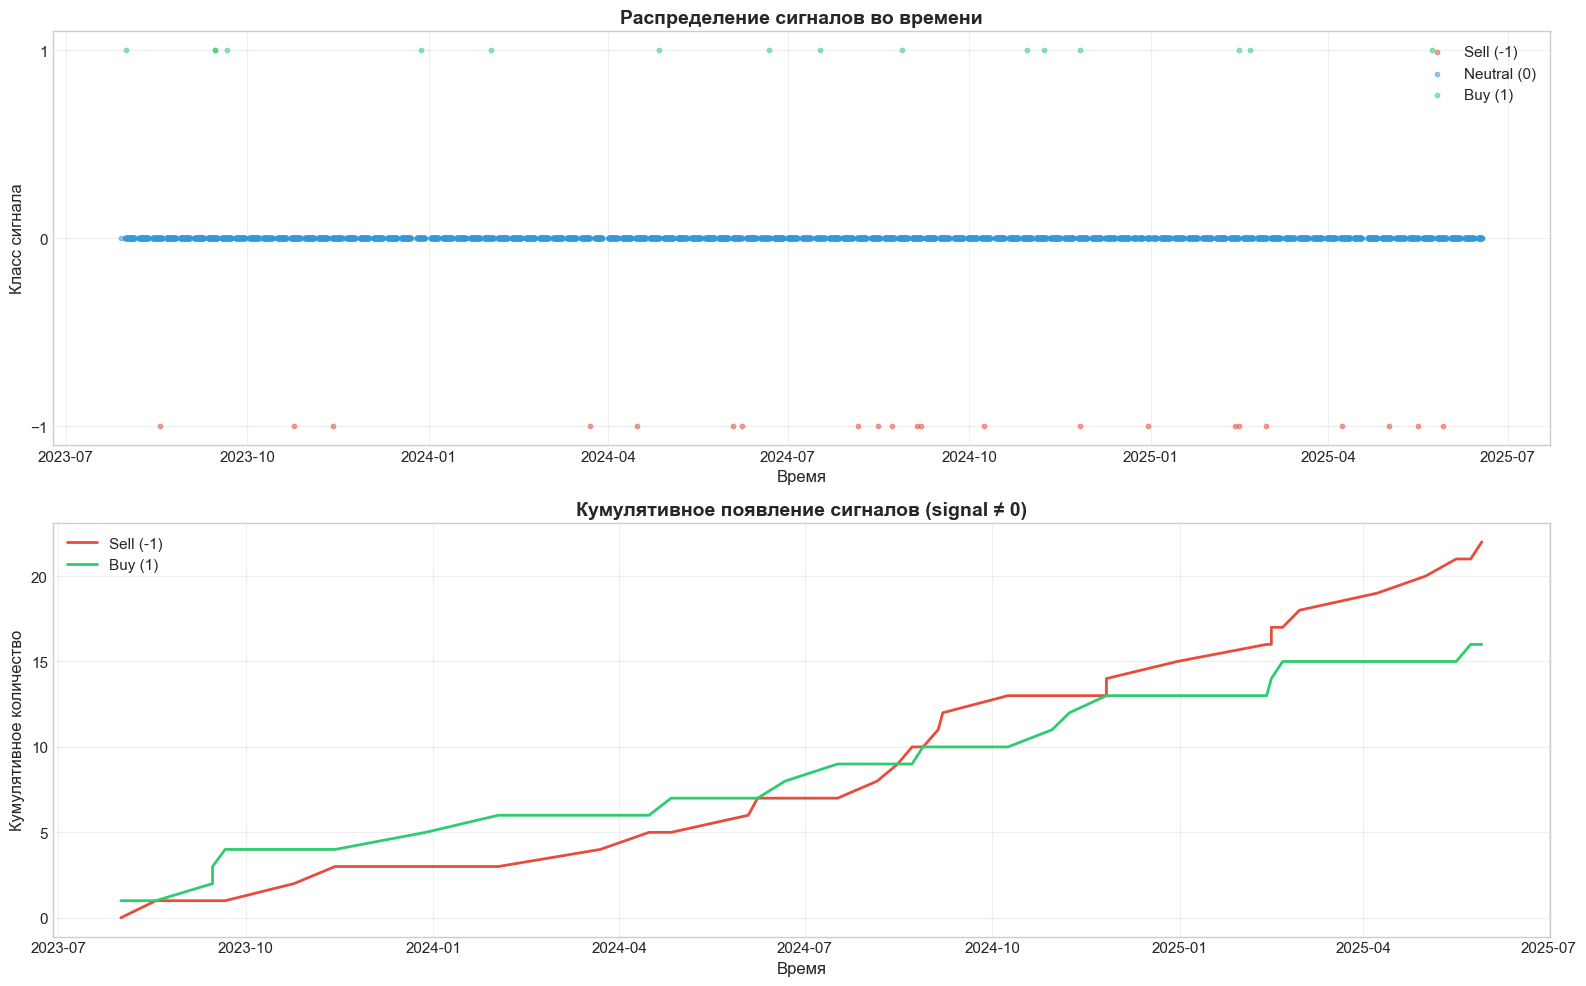

✅ Временные графики сохранены в plots/signals_over_time.png


In [15]:
# График появления сигналов во времени
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Все сигналы
available_signals_time = sorted(fractal_0_df['signal'].unique())
for signal in available_signals_time:
    signal_data = fractal_0_df[fractal_0_df['signal'] == signal]
    axes[0].scatter(signal_data['datetime'], [signal]*len(signal_data), 
                    alpha=0.5, s=10, c=CLASS_COLORS.get(signal, '#808080'), label=CLASS_NAMES.get(signal, f'Class {signal}'))

axes[0].set_title('Распределение сигналов во времени', fontweight='bold')
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Класс сигнала')
axes[0].legend()
axes[0].set_yticks([-1, 0, 1])
axes[0].grid(True, alpha=0.3)

# Только non-zero сигналы (кумулятивный график)
nonzero_signals = fractal_0_df[fractal_0_df['signal'] != 0].sort_values('datetime')

if len(nonzero_signals) > 0:
    # Кумулятивный подсчёт
    nonzero_signals = nonzero_signals.copy()
    nonzero_signals['cumcount_sell'] = (nonzero_signals['signal'] == -1).cumsum()
    nonzero_signals['cumcount_buy'] = (nonzero_signals['signal'] == 1).cumsum()
    
    axes[1].plot(nonzero_signals['datetime'], nonzero_signals['cumcount_sell'], 
                 color=CLASS_COLORS.get(-1, '#e74c3c'), label='Sell (-1)', linewidth=2)
    axes[1].plot(nonzero_signals['datetime'], nonzero_signals['cumcount_buy'], 
                 color=CLASS_COLORS.get(1, '#2ecc71'), label='Buy (1)', linewidth=2)
else:
    axes[1].text(0.5, 0.5, 'Нет non-zero сигналов', ha='center', va='center', fontsize=14, transform=axes[1].transAxes)

axes[1].set_title('Кумулятивное появление сигналов (signal ≠ 0)', fontweight='bold')
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Кумулятивное количество')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}signals_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Временные графики сохранены в {PLOTS_DIR}signals_over_time.png")

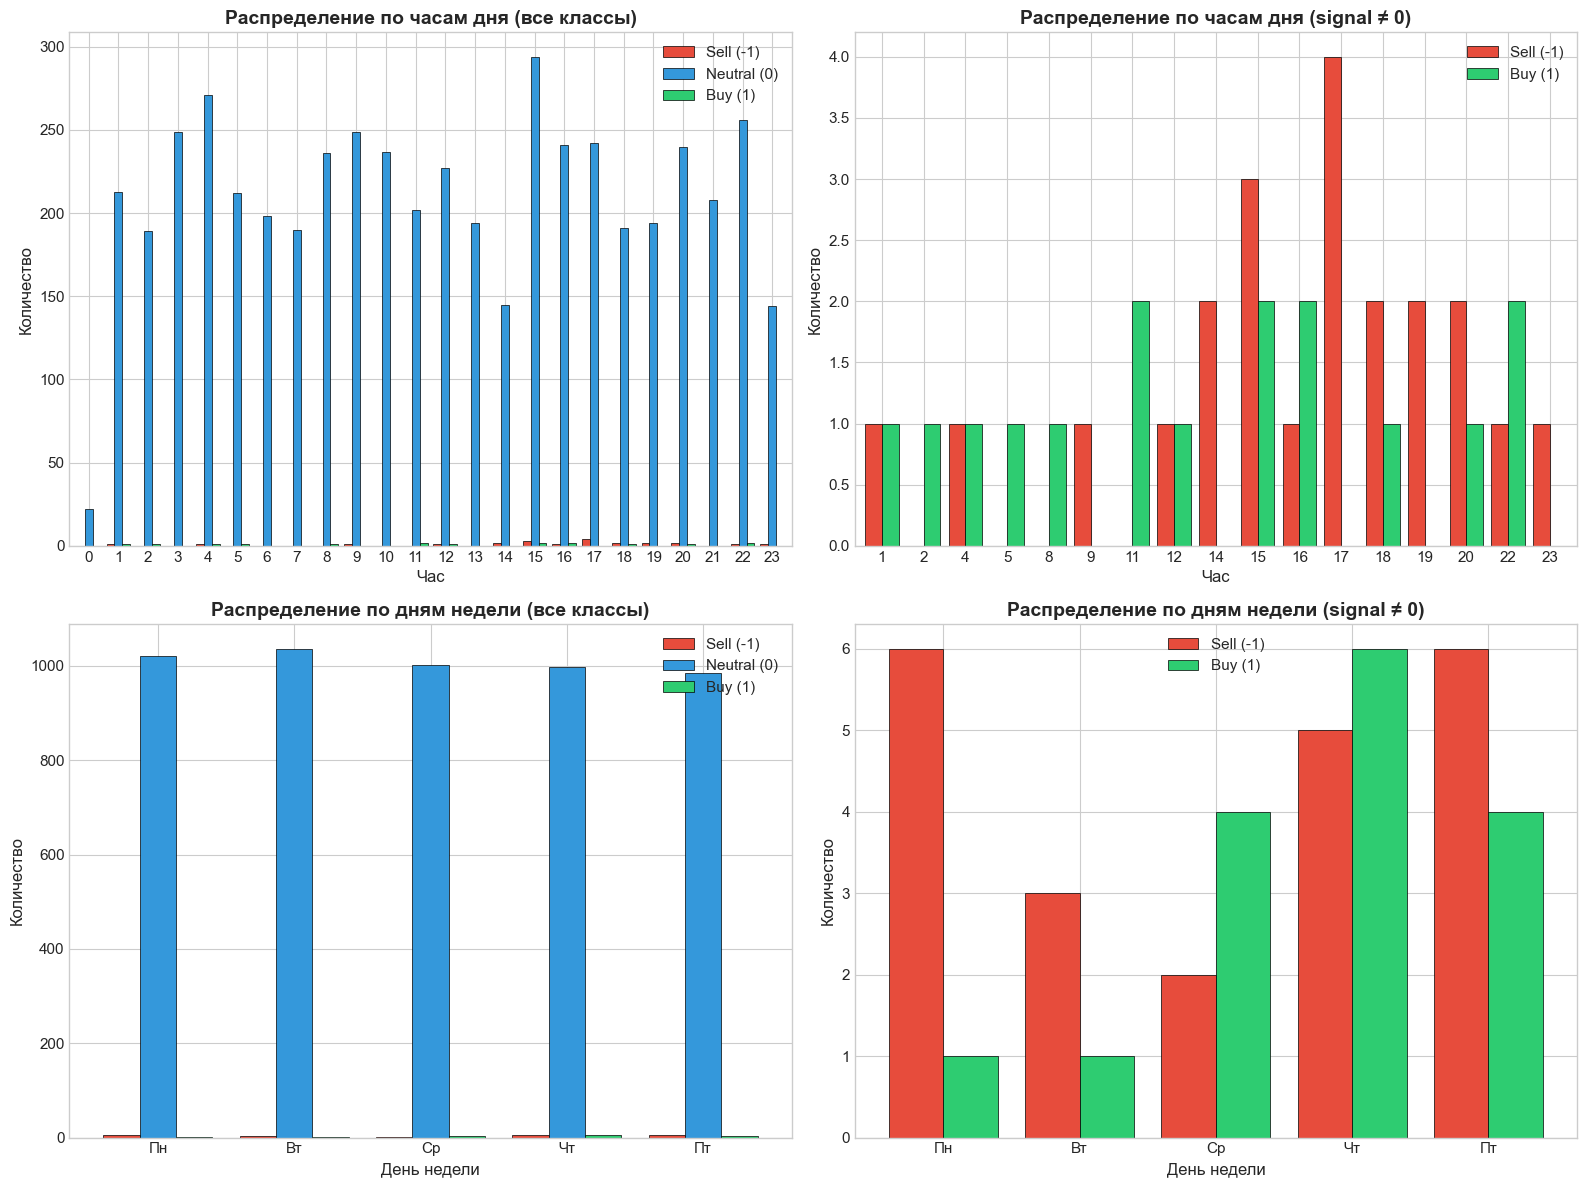

✅ Анализ сезонности сохранён в plots/seasonality_analysis.png


In [16]:
# Анализ сезонности: по часам дня и дням недели
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

day_names_full = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

# 1. Распределение по часам (все сигналы)
hour_counts = fractal_0_df.groupby(['hour', 'signal']).size().unstack(fill_value=0)
hour_counts[[c for c in [-1, 0, 1] if c in hour_counts.columns]].plot(
    kind='bar', ax=axes[0, 0], color=[CLASS_COLORS.get(c, '#808080') for c in hour_counts.columns], 
    width=0.8, edgecolor='black', linewidth=0.5)
axes[0, 0].set_title('Распределение по часам дня (все классы)', fontweight='bold')
axes[0, 0].set_xlabel('Час')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].legend([CLASS_NAMES.get(c, f'Class {c}') for c in hour_counts.columns])

# 2. Распределение по часам (только non-zero)
nonzero_df = fractal_0_df[fractal_0_df['signal'] != 0]
hour_nonzero = nonzero_df.groupby(['hour', 'signal']).size().unstack(fill_value=0)
hour_nonzero.plot(kind='bar', ax=axes[0, 1], 
                  color=[CLASS_COLORS.get(c, '#808080') for c in hour_nonzero.columns], 
                  width=0.8, edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Распределение по часам дня (signal ≠ 0)', fontweight='bold')
axes[0, 1].set_xlabel('Час')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend([CLASS_NAMES.get(c, f'Class {c}') for c in hour_nonzero.columns])

# 3. Распределение по дням недели (все сигналы)
dow_counts = fractal_0_df.groupby(['day_of_week', 'signal']).size().unstack(fill_value=0)
dow_counts.plot(kind='bar', ax=axes[1, 0], 
                color=[CLASS_COLORS.get(c, '#808080') for c in dow_counts.columns], 
                width=0.8, edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Распределение по дням недели (все классы)', fontweight='bold')
axes[1, 0].set_xlabel('День недели')
axes[1, 0].set_ylabel('Количество')
# ИСПРАВЛЕНИЕ: используем только те дни, которые есть в данных
unique_days = sorted(dow_counts.index)
day_names = [day_names_full[d] for d in unique_days]
axes[1, 0].set_xticklabels(day_names)
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend([CLASS_NAMES.get(c, f'Class {c}') for c in dow_counts.columns])

# 4. Распределение по дням недели (только non-zero)
dow_nonzero = nonzero_df.groupby(['day_of_week', 'signal']).size().unstack(fill_value=0)
dow_nonzero.plot(kind='bar', ax=axes[1, 1], 
                 color=[CLASS_COLORS.get(c, '#808080') for c in dow_nonzero.columns], 
                 width=0.8, edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('Распределение по дням недели (signal ≠ 0)', fontweight='bold')
axes[1, 1].set_xlabel('День недели')
axes[1, 1].set_ylabel('Количество')
# ИСПРАВЛЕНИЕ: используем только те дни, которые есть в данных
unique_days_nonzero = sorted(dow_nonzero.index)
day_names_nonzero = [day_names_full[d] for d in unique_days_nonzero]
axes[1, 1].set_xticklabels(day_names_nonzero)
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend([CLASS_NAMES.get(c, f'Class {c}') for c in dow_nonzero.columns])

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}seasonality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Анализ сезонности сохранён в {PLOTS_DIR}seasonality_analysis.png")


АНАЛИЗ КЛАСТЕРИЗАЦИИ СОБЫТИЙ (signal ≠ 0)

Статистика межсобытийных интервалов:
  Всего событий: 38
  Среднее время между событиями: 433.0 часов
  Медиана: 359.0 часов
  Std: 344.3 часов
  Min: 0.0 часов
  Max: 1201.0 часов

📊 Индекс дисперсии (variance/mean): 273.72
   (>1 указывает на кластеризацию событий)


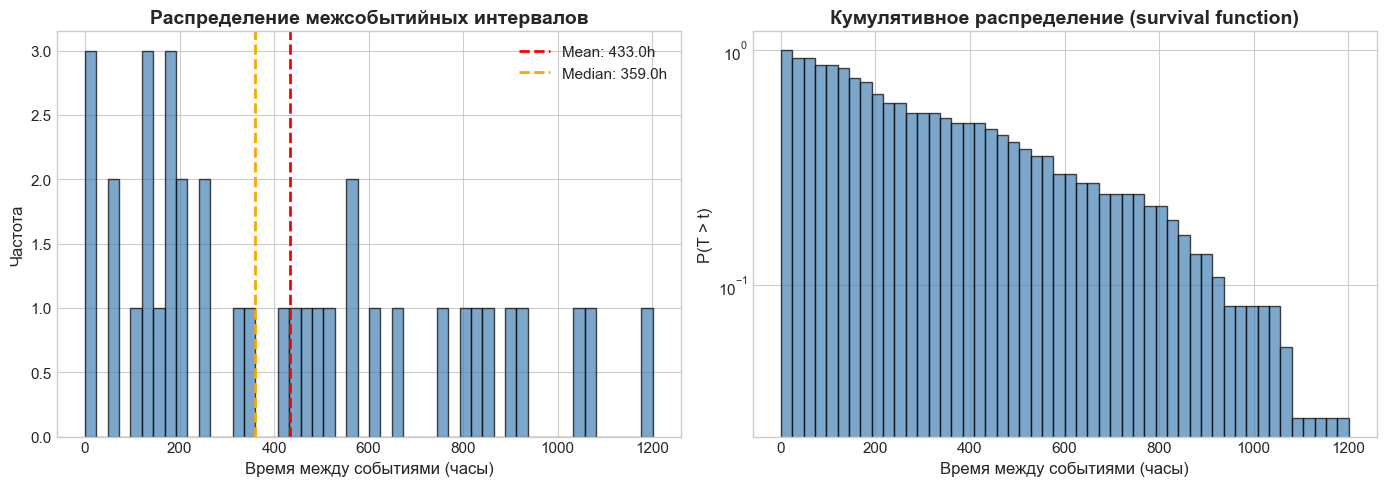


✅ Анализ кластеризации сохранён в plots/event_clustering.png


In [17]:
# Проверка кластеризации событий (межсобытийные интервалы)
print("\n" + "=" * 80)
print("АНАЛИЗ КЛАСТЕРИЗАЦИИ СОБЫТИЙ (signal ≠ 0)")
print("=" * 80)

nonzero_sorted = fractal_0_df[fractal_0_df['signal'] != 0].sort_values('fractal_time')
time_diffs = nonzero_sorted['fractal_time'].diff().dropna()
time_diffs_hours = time_diffs / 3600  # Конвертация в часы

print(f"\nСтатистика межсобытийных интервалов:")
print(f"  Всего событий: {len(nonzero_sorted)}")
print(f"  Среднее время между событиями: {time_diffs_hours.mean():.1f} часов")
print(f"  Медиана: {time_diffs_hours.median():.1f} часов")
print(f"  Std: {time_diffs_hours.std():.1f} часов")
print(f"  Min: {time_diffs_hours.min():.1f} часов")
print(f"  Max: {time_diffs_hours.max():.1f} часов")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма межсобытийных интервалов
axes[0].hist(time_diffs_hours, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(time_diffs_hours.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {time_diffs_hours.mean():.1f}h')
axes[0].axvline(time_diffs_hours.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {time_diffs_hours.median():.1f}h')
axes[0].set_title('Распределение межсобытийных интервалов', fontweight='bold')
axes[0].set_xlabel('Время между событиями (часы)')
axes[0].set_ylabel('Частота')
axes[0].legend()

# Проверка на кластеризацию: соотношение variance/mean
# Для Пуассоновского процесса = 1, >1 указывает на кластеризацию
dispersion_index = time_diffs_hours.var() / time_diffs_hours.mean()
print(f"\n📊 Индекс дисперсии (variance/mean): {dispersion_index:.2f}")
print(f"   (>1 указывает на кластеризацию событий)")

# Log-log график для проверки power-law
axes[1].hist(time_diffs_hours, bins=50, cumulative=-1, density=True, 
             color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_title('Кумулятивное распределение (survival function)', fontweight='bold')
axes[1].set_xlabel('Время между событиями (часы)')
axes[1].set_ylabel('P(T > t)')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}event_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Анализ кластеризации сохранён в {PLOTS_DIR}event_clustering.png")

## 6. Анализ выбросов

In [18]:
def analyze_outliers(df: pd.DataFrame, features: list) -> pd.DataFrame:
    """
    Анализ выбросов с использованием IQR и квантильного методов.
    
    Returns:
        DataFrame с информацией о выбросах для каждого признака
    """
    outlier_stats = []
    
    for feature in features:
        values = df[feature].dropna()
        
        # IQR метод
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        iqr_outliers_low = (values < lower_bound).sum()
        iqr_outliers_high = (values > upper_bound).sum()
        
        # Квантильный метод (1%, 99%)
        p01, p99 = values.quantile([0.01, 0.99])
        quantile_outliers_low = (values < p01).sum()
        quantile_outliers_high = (values > p99).sum()
        
        outlier_stats.append({
            'feature': feature,
            'total_values': len(values),
            'q1': q1,
            'q3': q3,
            'iqr': iqr,
            'iqr_lower_bound': lower_bound,
            'iqr_upper_bound': upper_bound,
            'iqr_outliers_low': iqr_outliers_low,
            'iqr_outliers_high': iqr_outliers_high,
            'iqr_outliers_pct': (iqr_outliers_low + iqr_outliers_high) / len(values) * 100,
            'p01': p01,
            'p99': p99,
            'quantile_outliers_low': quantile_outliers_low,
            'quantile_outliers_high': quantile_outliers_high
        })
    
    return pd.DataFrame(outlier_stats)

# Анализ выбросов
outlier_df = analyze_outliers(fractal_0_df, analysis_features)

print("=" * 100)
print("АНАЛИЗ ВЫБРОСОВ (IQR МЕТОД)")
print("=" * 100)

display_cols = ['feature', 'iqr_lower_bound', 'iqr_upper_bound', 
                'iqr_outliers_low', 'iqr_outliers_high', 'iqr_outliers_pct']
print(outlier_df[display_cols].round(4).to_string(index=False))

print("\n" + "=" * 100)
print("КВАНТИЛЬНЫЙ АНАЛИЗ (1%, 99%)")
print("=" * 100)

quantile_cols = ['feature', 'p01', 'p99', 'quantile_outliers_low', 'quantile_outliers_high']
print(outlier_df[quantile_cols].round(4).to_string(index=False))

# Сохранение
outlier_df.to_csv(f'{PLOTS_DIR}outlier_analysis.csv', index=False)
print(f"\n✅ Анализ выбросов сохранён в {PLOTS_DIR}outlier_analysis.csv")

АНАЛИЗ ВЫБРОСОВ (IQR МЕТОД)
  feature  iqr_lower_bound  iqr_upper_bound  iqr_outliers_low  iqr_outliers_high  iqr_outliers_pct
    price           0.4584           1.2511               504                  0            9.9174
direction          -4.0000           4.0000                 0                  0            0.0000
    front          -2.4154           6.8659                 0                603           11.8654
     back          -0.5631           2.9892                 0                272            5.3522
   strong           0.0000           0.0000                 0                  0            0.0000
    break           0.0000           0.0000                 0                  0            0.0000
  reverse          -1.5000           2.5000                 0                  0            0.0000
    power          -6.9235          12.6639                 0                251            4.9390
    count          -1.0000           7.0000                 0                 72 

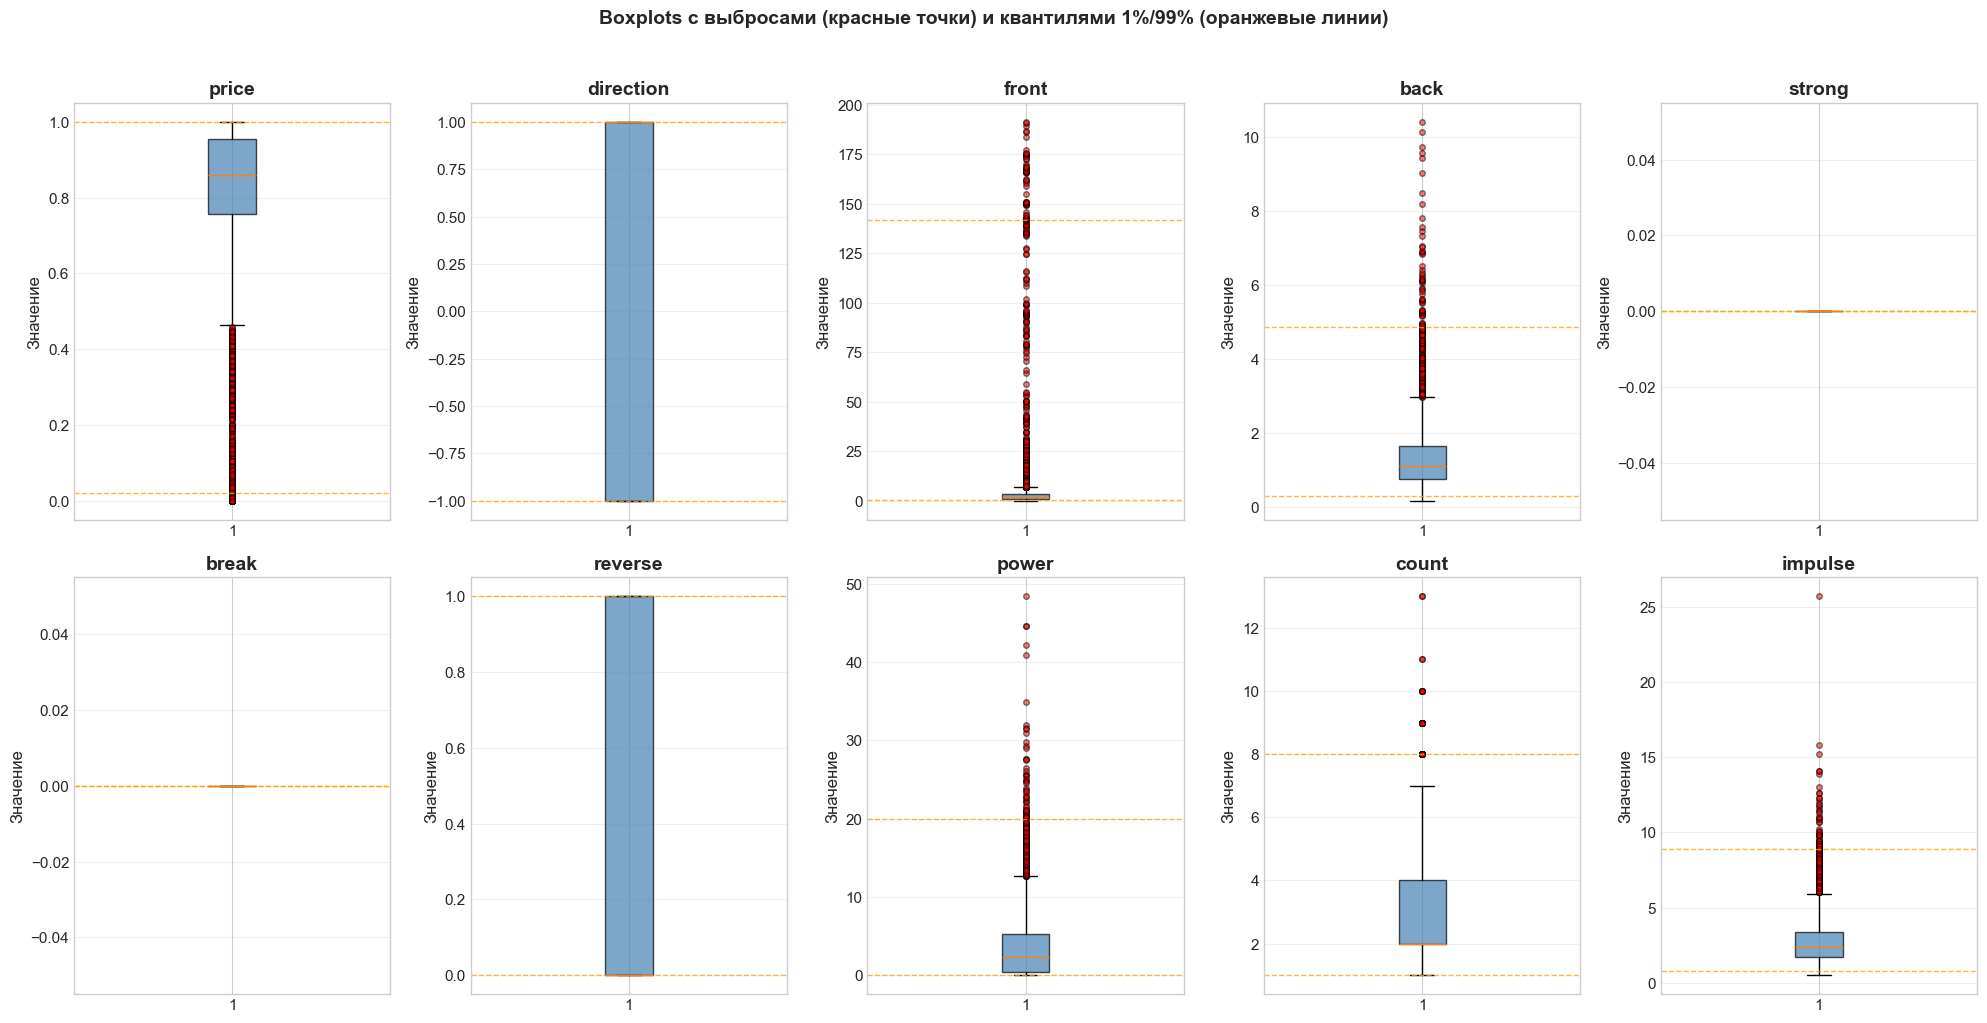

✅ Boxplots выбросов сохранены в plots/outliers_boxplots.png


In [19]:
# Визуализация выбросов
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, feature in enumerate(analysis_features):
    ax = axes[idx]
    values = fractal_0_df[feature].dropna()
    
    # Boxplot с выделением выбросов
    bp = ax.boxplot(values, vert=True, patch_artist=True,
                    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 4, 'alpha': 0.5})
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.7)
    
    # Добавляем 1% и 99% квантили
    p01, p99 = values.quantile([0.01, 0.99])
    ax.axhline(p01, color='orange', linestyle='--', linewidth=1, alpha=0.8, label='1%')
    ax.axhline(p99, color='orange', linestyle='--', linewidth=1, alpha=0.8, label='99%')
    
    ax.set_title(feature, fontweight='bold')
    ax.set_ylabel('Значение')
    ax.grid(True, alpha=0.3, axis='y')

# Скрываем лишний subplot
if len(analysis_features) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Boxplots с выбросами (красные точки) и квантилями 1%/99% (оранжевые линии)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}outliers_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Boxplots выбросов сохранены в {PLOTS_DIR}outliers_boxplots.png")

## 7. Dimension Reduction (t-SNE)

In [20]:
# Подготовка данных для t-SNE
# Исключаем fractal_time и константные признаки
tsne_features = [f for f in FEATURE_NAMES if f not in ['fractal_time', 'strong', 'break']]

print(f"Признаки для t-SNE: {tsne_features}")

# Подготовка матрицы признаков
X = fractal_0_df[tsne_features].values
y = fractal_0_df['signal'].values

print(f"Размерность X: {X.shape}")
print(f"Классы в y: {np.unique(y)}")

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nДанные стандартизированы.")

Признаки для t-SNE: ['price', 'direction', 'front', 'back', 'reverse', 'power', 'count', 'impulse']
Размерность X: (5082, 8)
Классы в y: [-1  0  1]

Данные стандартизированы.


In [21]:
# t-SNE проекция
print("Выполнение t-SNE... (может занять несколько минут)")

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, 
            learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_scaled)

print(f"t-SNE завершён. Размерность результата: {X_tsne.shape}")

Выполнение t-SNE... (может занять несколько минут)


t-SNE завершён. Размерность результата: (5082, 2)


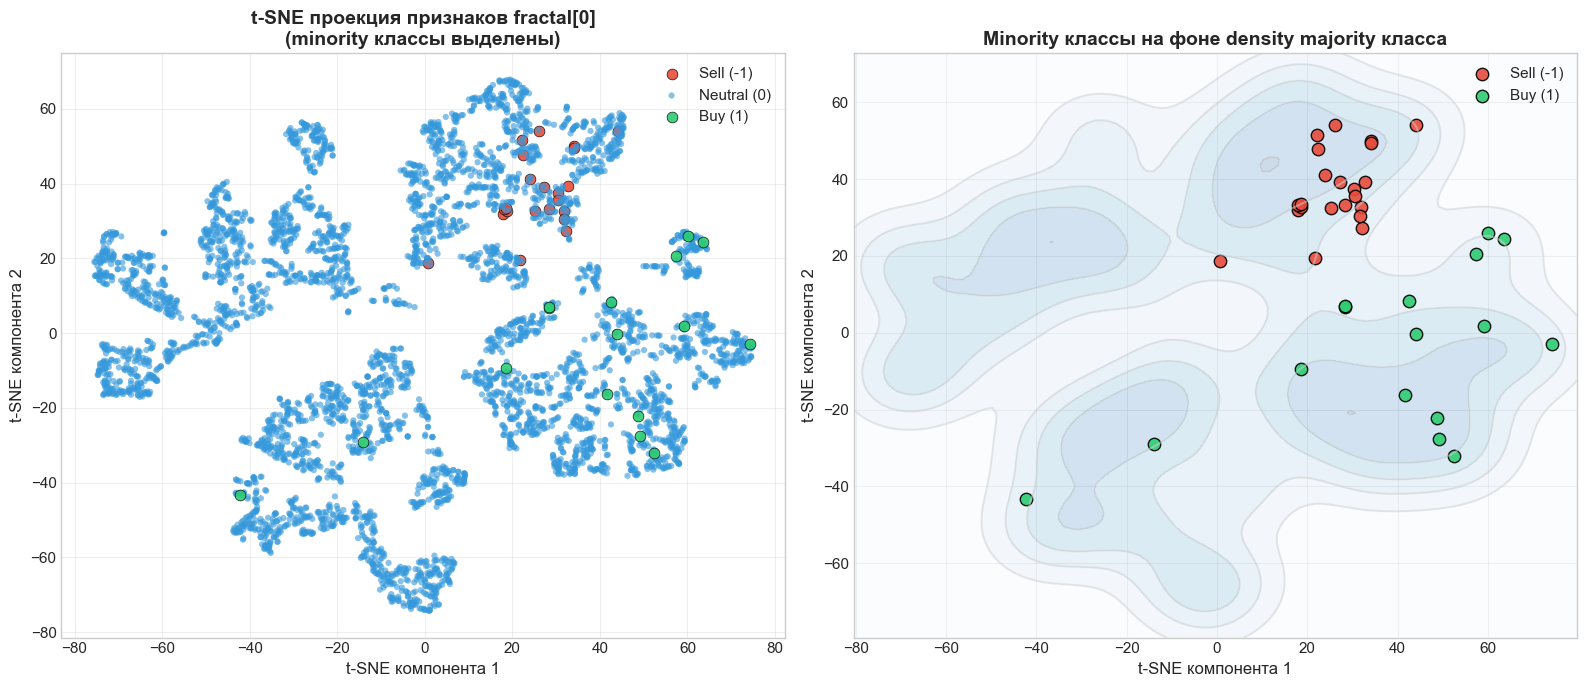

✅ t-SNE проекция сохранена в plots/tsne_projection.png


In [22]:
# Визуализация t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Все классы вместе
available_signals_tsne = sorted(np.unique(y))
for signal in available_signals_tsne:
    mask = y == signal
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                    c=CLASS_COLORS.get(signal, '#808080'), label=CLASS_NAMES.get(signal, f'Class {signal}'),
                    alpha=0.6 if signal == 0 else 0.9,
                    s=20 if signal == 0 else 60,
                    edgecolors='black' if signal != 0 else 'none',
                    linewidths=0.5)

axes[0].set_title('t-SNE проекция признаков fractal[0]\n(minority классы выделены)', fontweight='bold')
axes[0].set_xlabel('t-SNE компонента 1')
axes[0].set_ylabel('t-SNE компонента 2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Только minority классы на фоне контура majority
# Контур density для класса 0
mask_0 = y == 0
from scipy.stats import gaussian_kde
try:
    xy_0 = np.vstack([X_tsne[mask_0, 0], X_tsne[mask_0, 1]])
    kde = gaussian_kde(xy_0)
    
    # Создаём сетку
    xmin, xmax = X_tsne[:, 0].min() - 5, X_tsne[:, 0].max() + 5
    ymin, ymax = X_tsne[:, 1].min() - 5, X_tsne[:, 1].max() + 5
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    
    axes[1].contour(xx, yy, zz, levels=5, colors='lightgray', alpha=0.5)
    axes[1].contourf(xx, yy, zz, levels=5, cmap='Blues', alpha=0.2)
except:
    # Fallback если KDE не работает
    axes[1].scatter(X_tsne[mask_0, 0], X_tsne[mask_0, 1], 
                    c='lightgray', alpha=0.1, s=5)

# Minority классы (все кроме 0)
minority_signals = [s for s in available_signals_tsne if s != 0]
for signal in minority_signals:
    mask = y == signal
    if mask.sum() > 0:
        axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=CLASS_COLORS.get(signal, '#808080'), label=CLASS_NAMES.get(signal, f'Class {signal}'),
                        alpha=0.9, s=80, edgecolors='black', linewidths=1)

axes[1].set_title('Minority классы на фоне density majority класса', fontweight='bold')
axes[1].set_xlabel('t-SNE компонента 1')
axes[1].set_ylabel('t-SNE компонента 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}tsne_projection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ t-SNE проекция сохранена в {PLOTS_DIR}tsne_projection.png")

In [23]:
# Анализ разделимости классов
print("\n" + "=" * 80)
print("АНАЛИЗ РАЗДЕЛИМОСТИ КЛАССОВ В t-SNE ПРОСТРАНСТВЕ")
print("=" * 80)

# Вычисление центроидов
centroids = {}
available_signals_centroid = sorted(np.unique(y))
for signal in available_signals_centroid:
    mask = y == signal
    if mask.sum() > 0:
        centroids[signal] = X_tsne[mask].mean(axis=0)
        print(f"\nЦентроид класса {CLASS_NAMES.get(signal, f'Class {signal}')}: ({centroids[signal][0]:.2f}, {centroids[signal][1]:.2f})")

# Расстояния между центроидами
print("\nРасстояния между центроидами:")
for c1 in available_signals_centroid:
    for c2 in available_signals_centroid:
        if c1 < c2 and c1 in centroids and c2 in centroids:
            dist = np.linalg.norm(centroids[c1] - centroids[c2])
            print(f"  {CLASS_NAMES.get(c1, f'Class {c1}')} <-> {CLASS_NAMES.get(c2, f'Class {c2}')}: {dist:.2f}")

# Intra-class variance
print("\nВнутриклассовая дисперсия:")
for signal in available_signals_centroid:
    mask = y == signal
    if mask.sum() > 0:
        variance = X_tsne[mask].var()
        print(f"  {CLASS_NAMES.get(signal, f'Class {signal}')}: {variance:.2f}")


АНАЛИЗ РАЗДЕЛИМОСТИ КЛАССОВ В t-SNE ПРОСТРАНСТВЕ

Центроид класса Sell (-1): (26.03, 37.51)

Центроид класса Neutral (0): (-0.38, 0.48)

Центроид класса Buy (1): (38.22, -5.53)

Расстояния между центроидами:
  Sell (-1) <-> Neutral (0): 45.48
  Sell (-1) <-> Buy (1): 44.74
  Neutral (0) <-> Buy (1): 39.07

Внутриклассовая дисперсия:
  Sell (-1): 118.07
  Neutral (0): 1293.99
  Buy (1): 1110.30


## 8. Выводы и рекомендации

In [24]:
print("="*100)
print("ИТОГОВЫЕ ВЫВОДЫ EDA")
print("="*100)

print("""
1. ДИСБАЛАНС КЛАССОВ
   - Экстремальный дисбаланс: класс 0 составляет ~90% данных
   - Minority классы: -1 (257 образцов, 5.1%), +1 (240 образцов, 4.8%)
   - Требуется специальная обработка: oversampling, undersampling, или class weights

2. КЛЮЧЕВЫЕ ПРИЗНАКИ (по Cohen's d):
   - direction: полностью разделяет классы -1 и +1 (d → ∞)
   - impulse: различается между классами (выше для minority)
   - reverse: различается между классами
   - count: minority классы имеют отличные распределения

3. КОНСТАНТНЫЕ ПРИЗНАКИ:
   - strong и break: почти всегда 0 в fractal[0]
   - Рекомендуется проверить их в других фракталах

4. ВРЕМЕННЫЕ ПАТТЕРНЫ:
   - Проверить сезонность по часам и дням недели
   - Анализировать кластеризацию событий

5. t-SNE ВИЗУАЛИЗАЦИЯ:
   - Оценить визуальную разделимость классов
   - Minority классы могут образовывать кластеры

6. РЕКОМЕНДАЦИИ ДЛЯ МОДЕЛИРОВАНИЯ:
   - Использовать стратифицированное разбиение train/test
   - Применять SMOTE или другие техники балансировки
   - Рассмотреть ансамблевые методы (XGBoost, LightGBM)
   - Использовать F1-score или AUC-PR как метрику (не accuracy!)
   - Рассмотреть использование временных признаков
""")

print(f"\n✅ Все графики сохранены в папку: {PLOTS_DIR}")
print("✅ EDA завершён!")

ИТОГОВЫЕ ВЫВОДЫ EDA

1. ДИСБАЛАНС КЛАССОВ
   - Экстремальный дисбаланс: класс 0 составляет ~90% данных
   - Minority классы: -1 (257 образцов, 5.1%), +1 (240 образцов, 4.8%)
   - Требуется специальная обработка: oversampling, undersampling, или class weights

2. КЛЮЧЕВЫЕ ПРИЗНАКИ (по Cohen's d):
   - direction: полностью разделяет классы -1 и +1 (d → ∞)
   - impulse: различается между классами (выше для minority)
   - reverse: различается между классами
   - count: minority классы имеют отличные распределения

3. КОНСТАНТНЫЕ ПРИЗНАКИ:
   - strong и break: почти всегда 0 в fractal[0]
   - Рекомендуется проверить их в других фракталах

4. ВРЕМЕННЫЕ ПАТТЕРНЫ:
   - Проверить сезонность по часам и дням недели
   - Анализировать кластеризацию событий

5. t-SNE ВИЗУАЛИЗАЦИЯ:
   - Оценить визуальную разделимость классов
   - Minority классы могут образовывать кластеры

6. РЕКОМЕНДАЦИИ ДЛЯ МОДЕЛИРОВАНИЯ:
   - Использовать стратифицированное разбиение train/test
   - Применять SMOTE или другие т

In [25]:
# Сохранение ключевых данных для дальнейшего анализа
fractal_0_df.to_csv(f'{PLOTS_DIR}fractal_0_parsed.csv', index=False)
print(f"✅ Распарсенные данные fractal[0] сохранены в {PLOTS_DIR}fractal_0_parsed.csv")

# Сохранение t-SNE координат
tsne_df = pd.DataFrame({
    'tsne_1': X_tsne[:, 0],
    'tsne_2': X_tsne[:, 1],
    'signal': y
})
tsne_df.to_csv(f'{PLOTS_DIR}tsne_coordinates.csv', index=False)
print(f"✅ t-SNE координаты сохранены в {PLOTS_DIR}tsne_coordinates.csv")

✅ Распарсенные данные fractal[0] сохранены в plots/fractal_0_parsed.csv
✅ t-SNE координаты сохранены в plots/tsne_coordinates.csv


## 9. Анализ полной последовательности фракталов (n фракталов)

**Примечание:** Количество фракталов (`n_fractals`) определяется динамически из структуры CSV файла. Код адаптирован для работы с любым значением n (от 10 до 200+).

**Цель:** Комплексное исследование временных паттернов в полной последовательности фракталов и подготовка признаков для моделирования.

**Содержание:**
- 9.1 Парсинг и валидация полной последовательности
- 9.2 Статистика последовательности по классам
- 9.3 Feature Engineering из последовательности
- 9.4 Визуализация паттернов последовательности
- 9.5 Корреляционный анализ engineered features
- 9.6 Экспорт результатов

### 9.1 Парсинг и валидация полной последовательности

In [26]:
def parse_full_sequence(df: pd.DataFrame, fractal_cols: list, max_fractals: int = None) -> tuple:
    """
    Парсинг полной последовательности фракталов в 3D тензор.
    
    Args:
        df: исходный DataFrame с данными
        fractal_cols: список колонок с фракталами
        max_fractals: максимальное количество фракталов для парсинга
        
    Returns:
        X: np.array shape (n_samples, max_fractals, 11 features)
        y: np.array shape (n_samples,) — signal
        valid_mask: boolean mask для строк без ошибок парсинга
        parse_stats: dict со статистикой парсинга
    """
    n_samples = len(df)
    n_features = 11  # fractal_time, price, direction, front, back, strong, break, reverse, power, count, impulse
    
    # Динамическое определение количества фракталов, если не задано
    if max_fractals is None:
        max_fractals = len(fractal_cols)
    else:
        max_fractals = min(max_fractals, len(fractal_cols))
    
    # Инициализация тензора с NaN для отслеживания пропусков
    X = np.full((n_samples, max_fractals, n_features), np.nan)
    y = df['signal'].values.copy()
    valid_mask = np.ones(n_samples, dtype=bool)
    
    # Статистика парсинга
    parse_errors_per_position = np.zeros(max_fractals, dtype=int)
    parse_errors_per_row = np.zeros(n_samples, dtype=int)
    
    print(f"Парсинг {max_fractals} фракталов для {n_samples} строк...")
    
    for row_idx, row in df.iterrows():
        for f_idx in range(min(max_fractals, len(fractal_cols))):
            parsed = parse_fractal_string(row[fractal_cols[f_idx]])
            if parsed:
                X[row_idx, f_idx, 0] = parsed['fractal_time']
                X[row_idx, f_idx, 1] = parsed['price']
                X[row_idx, f_idx, 2] = parsed['direction']
                X[row_idx, f_idx, 3] = parsed['front']
                X[row_idx, f_idx, 4] = parsed['back']
                X[row_idx, f_idx, 5] = parsed['strong']
                X[row_idx, f_idx, 6] = parsed['break']
                X[row_idx, f_idx, 7] = parsed['reverse']
                X[row_idx, f_idx, 8] = parsed['power']
                X[row_idx, f_idx, 9] = parsed['count']
                X[row_idx, f_idx, 10] = parsed['impulse']
            else:
                parse_errors_per_position[f_idx] += 1
                parse_errors_per_row[row_idx] += 1
    
    # Строки с ошибками парсинга
    valid_mask = parse_errors_per_row == 0
    
    parse_stats = {
        'total_rows': n_samples,
        'valid_rows': valid_mask.sum(),
        'invalid_rows': (~valid_mask).sum(),
        'parse_rate': valid_mask.sum() / n_samples * 100,
        'errors_per_position': parse_errors_per_position,
        'errors_per_row': parse_errors_per_row
    }
    
    print(f"✅ Успешно распарсено: {parse_stats['valid_rows']} строк ({parse_stats['parse_rate']:.2f}%)")
    print(f"❌ Ошибки парсинга: {parse_stats['invalid_rows']} строк")
    
    return X, y, valid_mask, parse_stats

# Парсинг полной последовательности
# Используем n_fractals - 1, т.к. fractal[0] - самый новый, а fractal[n-1] - самый старый
X_full, y_full, valid_mask, parse_stats = parse_full_sequence(raw_df, fractal_cols, max_fractals=n_fractals)

print(f"\nРазмерность тензора X: {X_full.shape}")
print(f"Размерность вектора y: {y_full.shape}")

Парсинг 100 фракталов для 5082 строк...


✅ Успешно распарсено: 5082 строк (100.00%)
❌ Ошибки парсинга: 0 строк

Размерность тензора X: (5082, 100, 11)
Размерность вектора y: (5082,)


DATA QUALITY REPORT

1. MISSING VALUES по позициям фракталов:
   Позиции с пропусками: 0
   ✅ Пропусков не обнаружено!


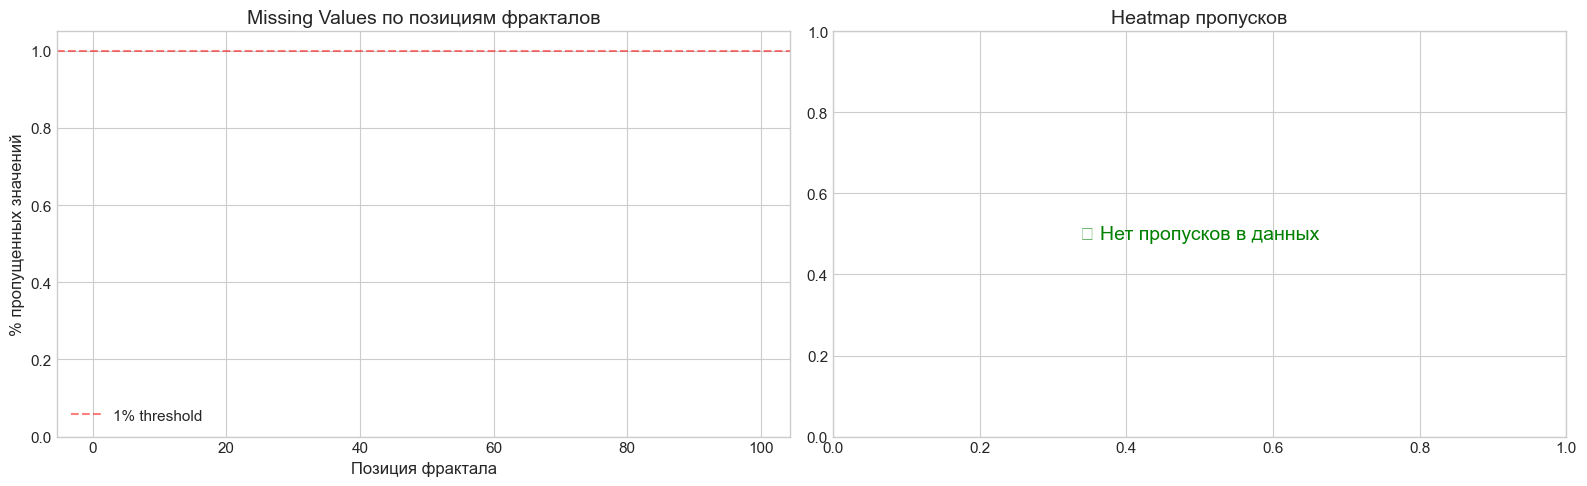


✅ График сохранён: plots/sequence_missing_values.png


In [27]:
# Data Quality проверки

# 1. Проверка missing values по позициям
missing_per_position = np.isnan(X_full[:, :, 0]).sum(axis=0)  # Проверяем по fractal_time
missing_rate_per_position = missing_per_position / len(X_full) * 100

print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)

print(f"\n1. MISSING VALUES по позициям фракталов:")
print(f"   Позиции с пропусками: {(missing_rate_per_position > 0).sum()}")
if missing_rate_per_position.max() > 0:
    print(f"   Максимальный % пропусков: {missing_rate_per_position.max():.2f}% на позиции {missing_rate_per_position.argmax()}")
else:
    print(f"   ✅ Пропусков не обнаружено!")

# 2. Heatmap: (row_index × fractal_position) → missing_rate
missing_matrix = np.isnan(X_full[:, :, 0]).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Общий график missing values по позициям
ax1 = axes[0]
ax1.bar(range(n_fractals), missing_rate_per_position, color='#e74c3c', alpha=0.7)
ax1.set_xlabel('Позиция фрактала')
ax1.set_ylabel('% пропущенных значений')
ax1.set_title('Missing Values по позициям фракталов')
ax1.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='1% threshold')
ax1.legend()

# Heatmap для первых 100 строк (если есть пропуски)
ax2 = axes[1]
if missing_matrix.sum() > 0:
    # Показываем только строки с пропусками
    rows_with_missing = np.where(missing_matrix.sum(axis=1) > 0)[0]
    if len(rows_with_missing) > 0:
        sample_size = min(100, len(rows_with_missing))
        sample_rows = rows_with_missing[:sample_size]
        im = ax2.imshow(missing_matrix[sample_rows], aspect='auto', cmap='Reds')
        ax2.set_xlabel('Позиция фрактала')
        ax2.set_ylabel('Индекс строки (с пропусками)')
        ax2.set_title(f'Heatmap пропусков (первые {sample_size} строк с пропусками)')
        plt.colorbar(im, ax=ax2, label='Missing (1) / Present (0)')
    else:
        ax2.text(0.5, 0.5, 'Нет пропусков для отображения', ha='center', va='center', fontsize=14)
        ax2.set_title('Heatmap пропусков')
else:
    ax2.text(0.5, 0.5, '✅ Нет пропусков в данных', ha='center', va='center', fontsize=14, color='green')
    ax2.set_title('Heatmap пропусков')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}sequence_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ График сохранён: {PLOTS_DIR}sequence_missing_values.png")

In [28]:
# Causal Consistency валидация (КРИТИЧНО для выявления data leakage)

print("\n" + "=" * 60)
print("CAUSAL CONSISTENCY VALIDATION")
print("=" * 60)

# Проверка: фракталы упорядочены по времени (от новых к старым)?
# fractal[0] должен быть самым новым, fractal[98] - самым старым
# т.е. fractal_time должен убывать: fractal_time[0] >= fractal_time[1] >= ... >= fractal_time[98]

causal_violations = []
fractal_times = X_full[:, :, 0]  # (n_samples, n_fractals)

for i in range(len(X_full)):
    times = fractal_times[i]
    # Проверяем, что времена убывают (или равны)
    if not np.all(times[:-1] >= times[1:]):
        # Находим позиции нарушений
        violations_mask = times[:-1] < times[1:]
        violation_positions = np.where(violations_mask)[0]
        causal_violations.append({
            'row': i,
            'positions': violation_positions.tolist(),
            'times_at_violations': [(int(pos), times[pos], times[pos+1]) for pos in violation_positions[:3]]
        })

print(f"\n1. Проверка упорядоченности фракталов по времени:")
if len(causal_violations) == 0:
    print(f"   ✅ PASSED: Все {len(X_full)} строк корректно упорядочены (fractal_time убывает)")
else:
    print(f"   ❌ ISSUES DETECTED: {len(causal_violations)} строк с нарушениями!")
    print(f"   Примеры нарушений (первые 5):")
    for v in causal_violations[:5]:
        print(f"      Строка {v['row']}: позиции {v['positions'][:5]}...")

# Проверка эволюции признаков для одного и того же фрактала через несколько строк
print(f"\n2. Проверка эволюции признаков фрактала между строками:")

# Найдём уникальные фракталы по (fractal_time, direction) и отследим их эволюцию
# Для этого создадим словарь: (time, direction) -> [(row_idx, position, back, power, count), ...]
from collections import defaultdict

fractal_tracker = defaultdict(list)

# Ограничимся первыми 1000 строками для анализа
sample_rows = min(1000, len(X_full))

for row_idx in range(sample_rows):
    for pos in range(min(20, n_fractals)):  # Анализируем первые 20 позиций
        time_val = X_full[row_idx, pos, 0]
        direction_val = X_full[row_idx, pos, 2]
        back_val = X_full[row_idx, pos, 4]
        power_val = X_full[row_idx, pos, 8]
        count_val = X_full[row_idx, pos, 9]
        
        if not np.isnan(time_val):
            key = (int(time_val), int(direction_val))
            fractal_tracker[key].append({
                'row': row_idx,
                'position': pos,
                'back': back_val,
                'power': power_val,
                'count': count_val
            })

# Анализ фракталов, которые появляются в нескольких строках
multi_occurrence_fractals = {k: v for k, v in fractal_tracker.items() if len(v) > 1}

print(f"   Фракталов, появляющихся в нескольких строках: {len(multi_occurrence_fractals)}")

# Проверим монотонность признаков
monotonicity_violations = []

for (time_val, direction), occurrences in list(multi_occurrence_fractals.items())[:100]:
    # Сортируем по строке (времени)
    occurrences_sorted = sorted(occurrences, key=lambda x: x['row'])
    
    # Проверяем: back должен только расти или оставаться, position должен расти
    for i in range(len(occurrences_sorted) - 1):
        curr = occurrences_sorted[i]
        next_occ = occurrences_sorted[i + 1]
        
        # Position должен увеличиваться (фрактал становится "старше")
        if next_occ['position'] <= curr['position']:
            monotonicity_violations.append({
                'fractal': (time_val, direction),
                'type': 'position_not_increasing',
                'curr_row': curr['row'],
                'next_row': next_occ['row'],
                'curr_pos': curr['position'],
                'next_pos': next_occ['position']
            })

if len(monotonicity_violations) == 0:
    print(f"   ✅ PASSED: Позиции фракталов корректно увеличиваются между строками")
else:
    print(f"   ⚠️ ANOMALIES: {len(monotonicity_violations)} нарушений монотонности позиций")
    print(f"   (Это может быть нормально, если фрактал исчезает из окна наблюдения)")

# Итоговый статус Data Leakage Check
print("\n" + "=" * 60)
print("DATA LEAKAGE CHECK SUMMARY")
print("=" * 60)
if len(causal_violations) == 0:
    print("✅ STATUS: PASSED - Данные корректно упорядочены по времени")
    print("   Фракталы идут от новых (позиция 0) к старым (позиция 98)")
    print("   Data leakage из будущего НЕ ОБНАРУЖЕН")
else:
    print("❌ STATUS: ISSUES DETECTED - Требуется дополнительный анализ")
    print(f"   Обнаружено {len(causal_violations)} строк с нарушениями порядка")


CAUSAL CONSISTENCY VALIDATION

1. Проверка упорядоченности фракталов по времени:
   ✅ PASSED: Все 5082 строк корректно упорядочены (fractal_time убывает)

2. Проверка эволюции признаков фрактала между строками:
   Фракталов, появляющихся в нескольких строках: 1017
   ⚠️ ANOMALIES: 9 нарушений монотонности позиций
   (Это может быть нормально, если фрактал исчезает из окна наблюдения)

DATA LEAKAGE CHECK SUMMARY
✅ STATUS: PASSED - Данные корректно упорядочены по времени
   Фракталы идут от новых (позиция 0) к старым (позиция 98)
   Data leakage из будущего НЕ ОБНАРУЖЕН


### 9.2 Статистика последовательности по классам

9.2 СТАТИСТИКА ПОСЛЕДОВАТЕЛЬНОСТИ ПО КЛАССАМ


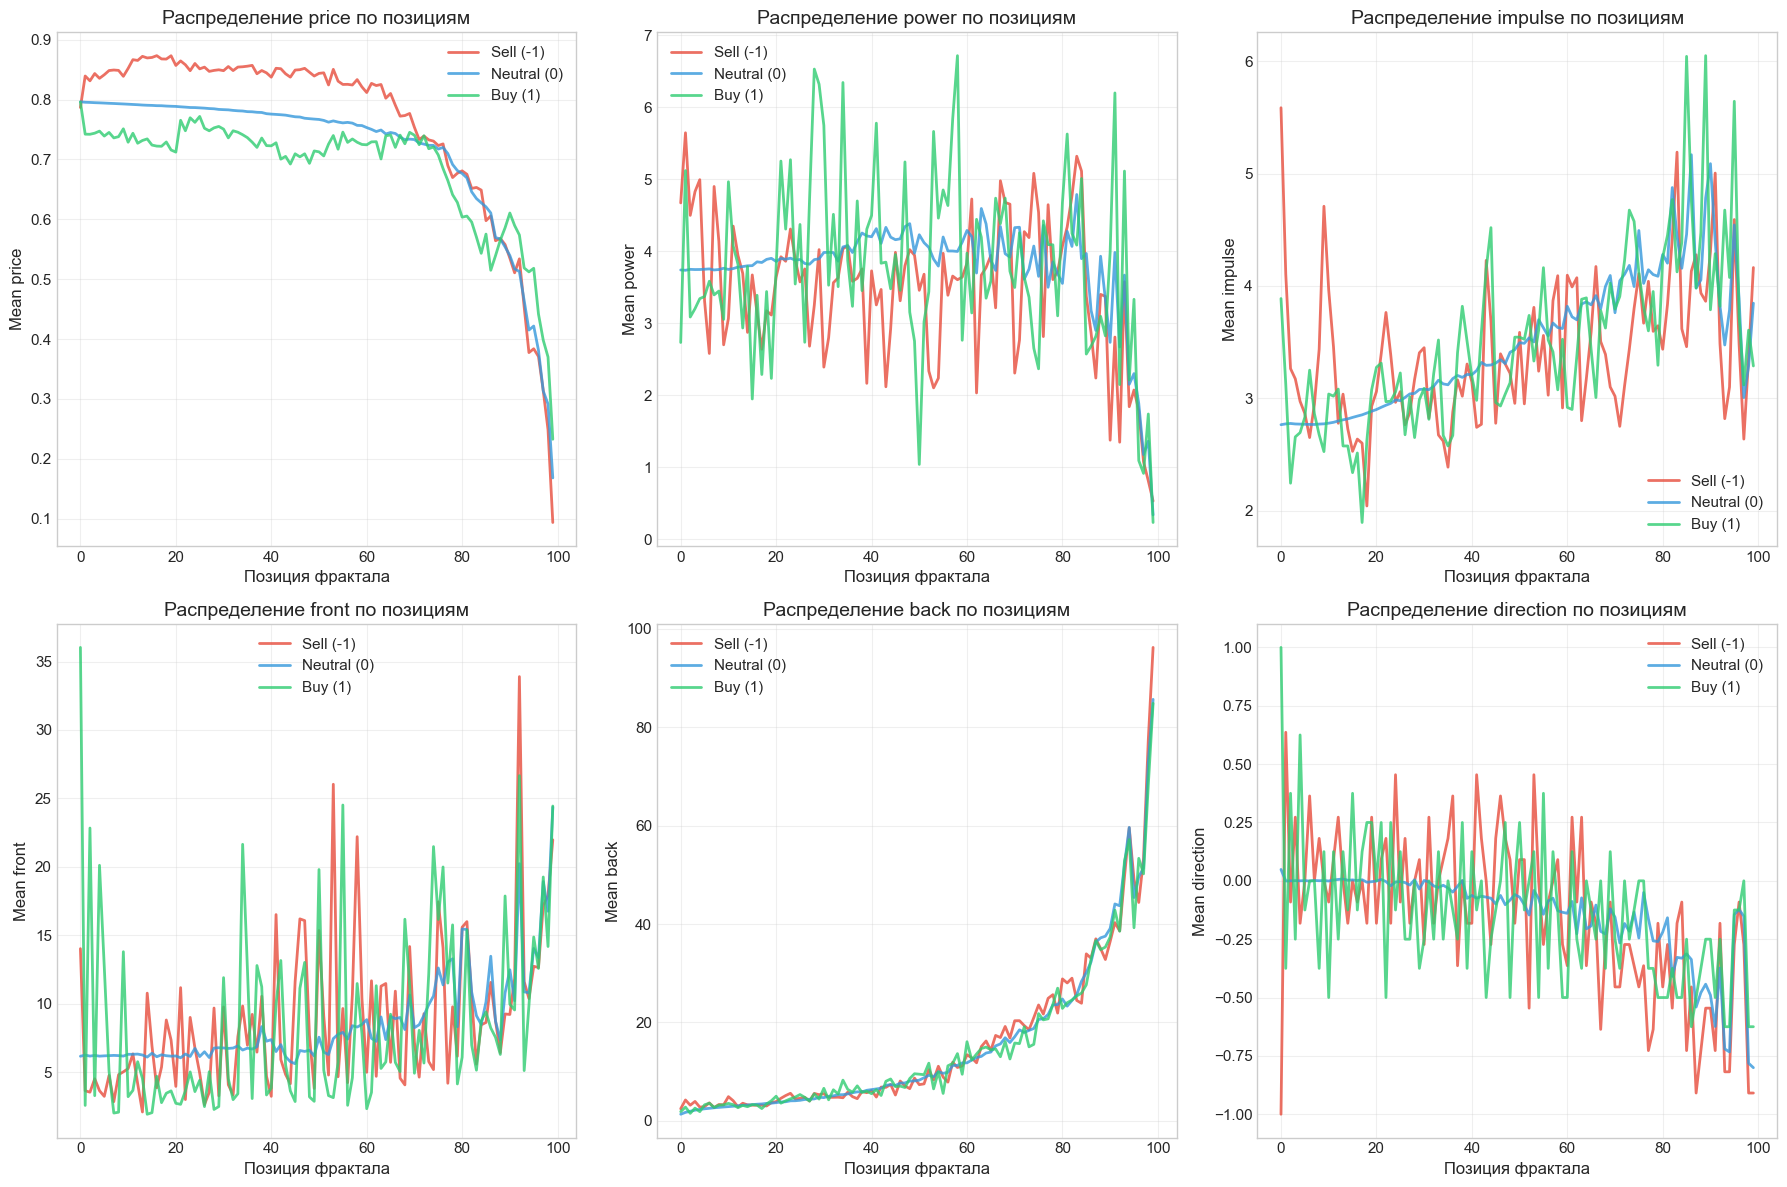

✅ График сохранён: plots/sequence_features_by_position.png


In [29]:
# Распределение признаков по позициям для каждого класса
print("=" * 60)
print("9.2 СТАТИСТИКА ПОСЛЕДОВАТЕЛЬНОСТИ ПО КЛАССАМ")
print("=" * 60)

# Индексы признаков
feature_idx_map = {
    'price': 1,
    'direction': 2,
    'front': 3,
    'back': 4,
    'power': 8,
    'impulse': 10
}

# Вычисление mean/std для каждой позиции по классам
classes = sorted(y_full[valid_mask].astype(int).tolist())
classes = sorted(set(classes))  # Уникальные классы
n_positions = n_fractals

# Для каждого признака и класса
stats_by_class = {}
for class_val in classes:
    mask = (y_full == class_val) & valid_mask
    if mask.sum() == 0:
        continue
    
    class_data = X_full[mask]  # (n_samples_class, n_fractals, 11)
    stats_by_class[class_val] = {
        'mean': np.nanmean(class_data, axis=0),  # (n_fractals, 11)
        'std': np.nanstd(class_data, axis=0),    # (n_fractals, 11)
        'n_samples': mask.sum()
    }

# Визуализация: распределение признаков по позициям
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

features_to_plot = ['price', 'power', 'impulse', 'front', 'back', 'direction']
for idx, feature in enumerate(features_to_plot):
    ax = axes[idx]
    feat_idx = feature_idx_map[feature]
    
    for class_val in classes:
        if class_val not in stats_by_class:
            continue
        means = stats_by_class[class_val]['mean'][:, feat_idx]
        positions = np.arange(len(means))
        
        # Исключаем NaN
        valid_mask_pos = ~np.isnan(means)
        ax.plot(positions[valid_mask_pos], means[valid_mask_pos], 
                label=CLASS_NAMES.get(class_val, f'Class {class_val}'), color=CLASS_COLORS.get(class_val, '#808080'), 
                linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Позиция фрактала')
    ax.set_ylabel(f'Mean {feature}')
    ax.set_title(f'Распределение {feature} по позициям')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}sequence_features_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ График сохранён: {PLOTS_DIR}sequence_features_by_position.png")

In [30]:
# Temporal patterns: анализ паттернов во времени
print("\n" + "=" * 60)
print("TEMPORAL PATTERNS АНАЛИЗ")
print("=" * 60)

temporal_stats = {}

for class_val in classes:
    mask = (y_full == class_val) & valid_mask
    if mask.sum() == 0:
        continue
    
    class_data = X_full[mask]
    directions = class_data[:, :, 2]  # (n_samples, n_fractals)
    
    # Количество смен direction в последовательности
    direction_changes = []
    longest_streaks = []
    price_volatilities = []
    
    for i in range(len(class_data)):
        dir_seq = directions[i]
        valid_dirs = dir_seq[~np.isnan(dir_seq)]
        
        if len(valid_dirs) > 1:
            # Смены direction
            changes = np.sum(valid_dirs[:-1] != valid_dirs[1:])
            direction_changes.append(changes)
            
            # Longest streak одного direction
            current_streak = 1
            max_streak = 1
            for j in range(1, len(valid_dirs)):
                if valid_dirs[j] == valid_dirs[j-1]:
                    current_streak += 1
                    max_streak = max(max_streak, current_streak)
                else:
                    current_streak = 1
            longest_streaks.append(max_streak)
        
        # Volatility последовательности (std price)
        prices = class_data[i, :, 1]  # price
        valid_prices = prices[~np.isnan(prices)]
        if len(valid_prices) > 1:
            price_volatilities.append(np.std(valid_prices))
    
    temporal_stats[class_val] = {
        'avg_direction_changes': np.mean(direction_changes) if direction_changes else 0,
        'avg_longest_streak': np.mean(longest_streaks) if longest_streaks else 0,
        'avg_volatility': np.mean(price_volatilities) if price_volatilities else 0,
        'n_samples': mask.sum()
    }

# Вывод статистики
print("\nTemporal patterns по классам:")
for class_val in classes:
    if class_val in temporal_stats:
        stats = temporal_stats[class_val]
        print(f"\n{class_val} ({CLASS_NAMES.get(class_val, f'Class {class_val}')}, n={stats['n_samples']}):")
        print(f"  Среднее количество смен direction: {stats['avg_direction_changes']:.2f}")
        print(f"  Средний longest streak: {stats['avg_longest_streak']:.2f}")
        print(f"  Средняя волатильность цены: {stats['avg_volatility']:.6f}")


TEMPORAL PATTERNS АНАЛИЗ



Temporal patterns по классам:

-1 (Sell (-1), n=22):
  Среднее количество смен direction: 54.59
  Средний longest streak: 11.36
  Средняя волатильность цены: 0.193353

0 (Neutral (0), n=5044):
  Среднее количество смен direction: 56.22
  Средний longest streak: 10.08
  Средняя волатильность цены: 0.190706

1 (Buy (1), n=16):
  Среднее количество смен direction: 55.81
  Средний longest streak: 9.75
  Средняя волатильность цены: 0.186952



ATTENTION-ПОДОБНЫЙ АНАЛИЗ


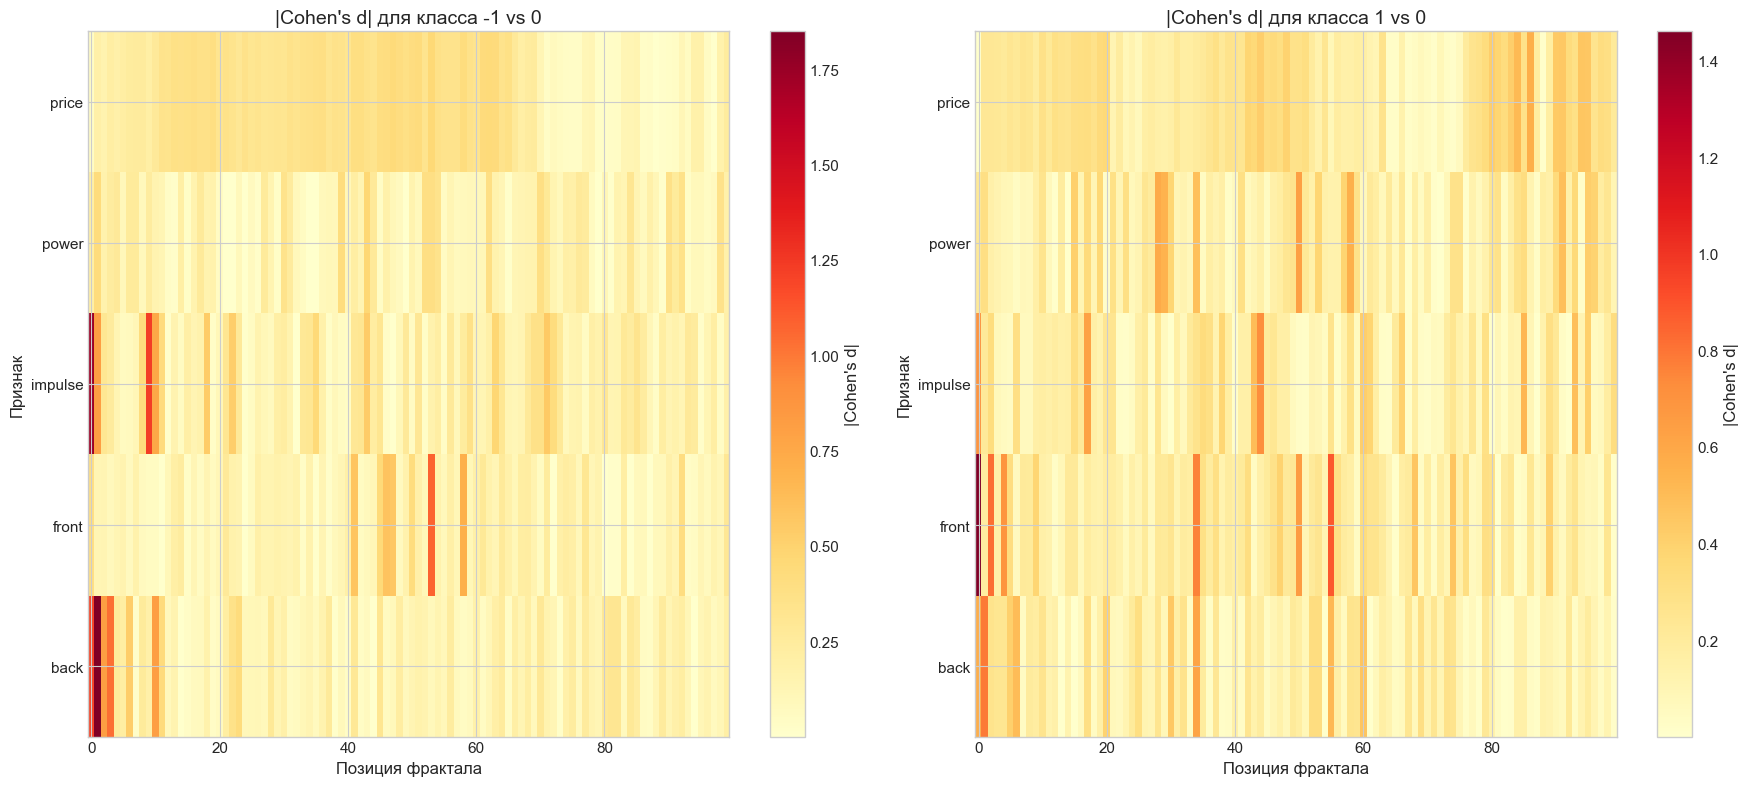


Топ-10 наиболее дискриминативных позиций (по |Cohen's d|):

Класс -1:
  Позиция 0: средний |Cohen's d| = 0.573
  Позиция 1: средний |Cohen's d| = 0.451
  Позиция 53: средний |Cohen's d| = 0.345
  Позиция 41: средний |Cohen's d| = 0.319
  Позиция 70: средний |Cohen's d| = 0.296
  Позиция 63: средний |Cohen's d| = 0.280
  Позиция 3: средний |Cohen's d| = 0.273
  Позиция 22: средний |Cohen's d| = 0.269
  Позиция 10: средний |Cohen's d| = 0.267
  Позиция 71: средний |Cohen's d| = 0.255

Класс 1:
  Позиция 0: средний |Cohen's d| = 0.456
  Позиция 34: средний |Cohen's d| = 0.405
  Позиция 2: средний |Cohen's d| = 0.387
  Позиция 55: средний |Cohen's d| = 0.385
  Позиция 1: средний |Cohen's d| = 0.297
  Позиция 50: средний |Cohen's d| = 0.293
  Позиция 21: средний |Cohen's d| = 0.292
  Позиция 60: средний |Cohen's d| = 0.283
  Позиция 4: средний |Cohen's d| = 0.278
  Позиция 29: средний |Cohen's d| = 0.272

✅ График сохранён: plots/attention_cohens_d_heatmap.png


In [31]:
# Attention-подобный анализ: какие позиции наиболее отличаются от класса 0
print("\n" + "=" * 60)
print("ATTENTION-ПОДОБНЫЙ АНАЛИЗ")
print("=" * 60)

# Cohen's d для каждой позиции отдельно
def cohens_d(x, y):
    """Вычисление Cohen's d между двумя выборками"""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    if pooled_std == 0:
        return 0
    return (np.mean(x) - np.mean(y)) / pooled_std

# Класс 0 как baseline
class_0_mask = (y_full == 0) & valid_mask
class_0_data = X_full[class_0_mask]

# Для minority классов
cohens_d_results = {}

for minority_class in [-1, 1]:
    mask = (y_full == minority_class) & valid_mask
    if mask.sum() == 0:
        continue
    
    minority_data = X_full[mask]
    
    # Для каждого признака и позиции
    cohens_matrix = np.full((n_fractals, 11), np.nan)
    
    for pos in range(n_fractals):
        for feat_idx in range(11):
            class_0_values = class_0_data[:, pos, feat_idx]
            minority_values = minority_data[:, pos, feat_idx]
            
            # Убираем NaN
            class_0_clean = class_0_values[~np.isnan(class_0_values)]
            minority_clean = minority_values[~np.isnan(minority_values)]
            
            if len(class_0_clean) > 10 and len(minority_clean) > 10:
                d = cohens_d(minority_clean, class_0_clean)
                cohens_matrix[pos, feat_idx] = d
    
    cohens_d_results[minority_class] = cohens_matrix

# Визуализация: Heatmap Cohen's d
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, minority_class in enumerate([-1, 1]):
    ax = axes[idx]
    matrix = np.abs(cohens_d_results[minority_class])
    
    # Только для ключевых признаков
    key_features = ['price', 'power', 'impulse', 'front', 'back']
    key_feat_indices = [feature_idx_map[f] for f in key_features]
    
    im = ax.imshow(matrix[:, key_feat_indices].T, aspect='auto', cmap='YlOrRd', 
                   interpolation='nearest')
    ax.set_xlabel('Позиция фрактала')
    ax.set_ylabel('Признак')
    ax.set_yticks(range(len(key_features)))
    ax.set_yticklabels(key_features)
    ax.set_title(f'|Cohen\'s d| для класса {minority_class} vs 0')
    plt.colorbar(im, ax=ax, label='|Cohen\'s d|')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}attention_cohens_d_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Топ-10 наиболее дискриминативных позиций
print("\nТоп-10 наиболее дискриминативных позиций (по |Cohen's d|):")
for minority_class in [-1, 1]:
    if minority_class not in cohens_d_results:
        continue
    matrix = np.abs(cohens_d_results[minority_class])
    # Усредняем по всем признакам для каждой позиции
    pos_scores = np.nanmean(matrix, axis=1)
    top_positions = np.argsort(pos_scores)[-10:][::-1]
    print(f"\nКласс {minority_class}:")
    for pos in top_positions:
        print(f"  Позиция {pos}: средний |Cohen's d| = {pos_scores[pos]:.3f}")

print(f"\n✅ График сохранён: {PLOTS_DIR}attention_cohens_d_heatmap.png")

In [32]:
### 9.3 Feature Engineering из последовательности

In [33]:
from sklearn.linear_model import LinearRegression
from scipy.stats import rankdata

def engineer_sequence_features(X: np.ndarray, y: np.ndarray, valid_mask: np.ndarray) -> pd.DataFrame:
    """
    Извлечение агрегированных признаков из последовательности фракталов.
    
    Args:
        X: тензор (n_samples, n_fractals, 11)
        y: вектор меток (n_samples,)
        valid_mask: маска валидных строк
        
    Returns:
        DataFrame с engineered features
    """
    n_samples = len(X)
    features_dict = {}
    
    # Индексы признаков
    price_idx = 1
    direction_idx = 2
    front_idx = 3
    back_idx = 4
    power_idx = 8
    count_idx = 9
    impulse_idx = 10
    
    print("Извлечение признаков из последовательности...")
    print("Это может занять несколько минут...")
    
    # A. Rolling Statistics
    windows = [1, 2, 3, 4, 5, 10, 20]
    feature_names_rolling = ['price', 'front', 'back', 'power', 'impulse', 'count']
    feature_indices_rolling = [price_idx, front_idx, back_idx, power_idx, impulse_idx, count_idx]
    
    for window in windows:
        for feat_name, feat_idx in zip(feature_names_rolling, feature_indices_rolling):
            # Rolling mean, std, min, max для последних 'window' фракталов
            rolling_data = X[:, :window, feat_idx]  # (n_samples, window)
            
            # Mean
            features_dict[f'{feat_name}_mean_w{window}'] = np.nanmean(rolling_data, axis=1)
            
            # Std
            features_dict[f'{feat_name}_std_w{window}'] = np.nanstd(rolling_data, axis=1)
            
            # Min
            features_dict[f'{feat_name}_min_w{window}'] = np.nanmin(rolling_data, axis=1)
            
            # Max
            features_dict[f'{feat_name}_max_w{window}'] = np.nanmax(rolling_data, axis=1)
    
    print(f"  ✅ Rolling statistics: {len(windows) * len(feature_names_rolling) * 4} признаков")
    
    # B. Trend Indicators (Linear regression slope)
    N_values = [2, 3, 4, 5, 10]
    trend_features = ['price', 'power', 'impulse']
    trend_indices = [price_idx, power_idx, impulse_idx]
    
    for N in N_values:
        for feat_name, feat_idx in zip(trend_features, trend_indices):
            slopes = []
            for i in range(n_samples):
                data = X[i, :N, feat_idx]
                valid_data = data[~np.isnan(data)]
                if len(valid_data) >= 2:
                    x = np.arange(len(valid_data))
                    if np.std(x) > 0:
                        slope = np.polyfit(x, valid_data, 1)[0]
                    else:
                        slope = 0
                else:
                    slope = np.nan
                slopes.append(slope)
            features_dict[f'{feat_name}_slope_{N}'] = slopes
    
    print(f"  ✅ Trend indicators: {len(N_values) * len(trend_features)} признаков")
    
    # C. Directional Patterns
    for N in [3, 5, 10, 20]:
        direction_changes = []
        peak_ratios = []
        longest_streaks = []
        majority_directions = []
        
        for i in range(n_samples):
            dirs = X[i, :N, direction_idx]
            valid_dirs = dirs[~np.isnan(dirs)]
            
            if len(valid_dirs) > 1:
                # Количество смен direction
                changes = np.sum(valid_dirs[:-1] != valid_dirs[1:])
                direction_changes.append(changes)
                
                # Ratio пиков к впадинам
                peaks = np.sum(valid_dirs == 1)
                valleys = np.sum(valid_dirs == -1)
                if valleys > 0:
                    ratio = peaks / valleys
                else:
                    ratio = peaks if peaks > 0 else 0
                peak_ratios.append(ratio)
                
                # Longest streak
                current_streak = 1
                max_streak = 1
                for j in range(1, len(valid_dirs)):
                    if valid_dirs[j] == valid_dirs[j-1]:
                        current_streak += 1
                        max_streak = max(max_streak, current_streak)
                    else:
                        current_streak = 1
                longest_streaks.append(max_streak)
                
                # Majority direction
                current_dir = valid_dirs[0] if len(valid_dirs) > 0 else 0
                majority_dir = 1 if np.sum(valid_dirs == 1) > np.sum(valid_dirs == -1) else -1
                majority_directions.append(1 if current_dir == majority_dir else 0)
            else:
                direction_changes.append(0)
                peak_ratios.append(0)
                longest_streaks.append(0)
                majority_directions.append(0)
        
        features_dict[f'direction_changes_w{N}'] = direction_changes
        features_dict[f'peak_valley_ratio_w{N}'] = peak_ratios
        features_dict[f'longest_streak_w{N}'] = longest_streaks
        features_dict[f'majority_direction_match_w{N}'] = majority_directions
    
    print(f"  ✅ Directional patterns: {len([3, 5, 10, 20]) * 4} признаков")
    
    # D. Relative Features (нормализация относительно окна)
    for window in [10, 20]:
        for feat_name, feat_idx in zip(['price', 'power'], [price_idx, power_idx]):
            # Z-score относительно окна
            z_scores = []
            percentiles = []
            
            for i in range(n_samples):
                window_data = X[i, :window, feat_idx]
                current_val = X[i, 0, feat_idx] if not np.isnan(X[i, 0, feat_idx]) else np.nan
                
                valid_window = window_data[~np.isnan(window_data)]
                if len(valid_window) > 1 and not np.isnan(current_val):
                    mean_w = np.mean(valid_window)
                    std_w = np.std(valid_window)
                    if std_w > 0:
                        z_score = (current_val - mean_w) / std_w
                    else:
                        z_score = 0
                    
                    # Percentile rank
                    percentile = (np.sum(valid_window <= current_val) / len(valid_window)) * 100
                else:
                    z_score = np.nan
                    percentile = np.nan
                
                z_scores.append(z_score)
                percentiles.append(percentile)
            
            features_dict[f'{feat_name}_zscore_w{window}'] = z_scores
            features_dict[f'{feat_name}_percentile_w{window}'] = percentiles
    
    print(f"  ✅ Relative features: {len([10, 20]) * 2 * 2} признаков")
    
    # E. Support/Resistance Indicators
    for window in [3, 5, 10, 20]:
        support_resistance = []
        for i in range(n_samples):
            price_current = X[i, 0, price_idx]
            prices_window = X[i, :window, price_idx]
            
            if not np.isnan(price_current):
                valid_prices = prices_window[~np.isnan(prices_window)]
                if len(valid_prices) > 0:
                    price_range = np.max(valid_prices) - np.min(valid_prices)
                    threshold = 0.02 * price_range if price_range > 0 else 0
                    count_similar = np.sum(np.abs(valid_prices - price_current) < threshold)
                else:
                    count_similar = 0
            else:
                count_similar = 0
            
            support_resistance.append(count_similar)
        
        features_dict[f'support_resistance_w{window}'] = support_resistance
    
    print(f"  ✅ Support/Resistance: {len([3, 5, 10, 20])} признаков")
    
    # F. Momentum & Volatility
    for N in [5, 10, 20]:
        # Cumulative direction
        cumsum_dirs = []
        for i in range(n_samples):
            dirs = X[i, :N, direction_idx]
            valid_dirs = dirs[~np.isnan(dirs)]
            if len(valid_dirs) > 0:
                cumsum_dirs.append(np.sum(valid_dirs))
            else:
                cumsum_dirs.append(0)
        features_dict[f'cumulative_direction_{N}'] = cumsum_dirs
        
        # Price momentum
        price_momentums = []
        for i in range(n_samples):
            prices = X[i, :N, price_idx]
            valid_prices = prices[~np.isnan(prices)]
            if len(valid_prices) >= 2:
                momentum = (valid_prices[0] - valid_prices[-1]) / len(valid_prices)
            else:
                momentum = 0
            price_momentums.append(momentum)
        features_dict[f'price_momentum_{N}'] = price_momentums
        
        # Volatility proxy
        volatilities = []
        for i in range(n_samples):
            prices = X[i, :N, price_idx]
            valid_prices = prices[~np.isnan(prices)]
            if len(valid_prices) > 1:
                mean_price = np.mean(valid_prices)
                if mean_price > 0:
                    volatility = np.std(valid_prices) / mean_price
                else:
                    volatility = 0
            else:
                volatility = 0
            volatilities.append(volatility)
        features_dict[f'volatility_proxy_{N}'] = volatilities
        
        # ATR analog
        atrs = []
        for i in range(n_samples):
            prices = X[i, :N, price_idx]
            valid_prices = prices[~np.isnan(prices)]
            if len(valid_prices) > 1:
                atr = np.mean(np.abs(np.diff(valid_prices)))
            else:
                atr = 0
            atrs.append(atr)
        features_dict[f'atr_analog_{N}'] = atrs
    
    print(f"  ✅ Momentum & Volatility: {len([5, 10, 20]) * 4} признаков")
    
    # G. Interaction Features
    # front * back
    features_dict['front_back_interaction'] = X[:, 0, front_idx] * X[:, 0, back_idx]
    
    # power * impulse
    features_dict['power_impulse_interaction'] = X[:, 0, power_idx] * X[:, 0, impulse_idx]
    
    # count * reverse
    features_dict['count_reverse_interaction'] = X[:, 0, count_idx] * X[:, 0, 7]  # reverse is index 7
    
    # (impulse - mean_impulse_w10) * direction
    impulse_means_w10 = np.nanmean(X[:, :10, impulse_idx], axis=1)
    features_dict['impulse_direction_interaction'] = (X[:, 0, impulse_idx] - impulse_means_w10) * X[:, 0, direction_idx]
    
    print(f"  ✅ Interaction features: 4 признака")
    
    # H. Time-based Features
    # Δt между fractal[0] и fractal[1], [2], [3], [4], [5]
    for offset in [1, 2, 3, 4, 5]:
        time_diffs = []
        for i in range(n_samples):
            time_0 = X[i, 0, 0]  # fractal_time at position 0
            time_offset = X[i, offset, 0] if offset < X.shape[1] else np.nan
            if not np.isnan(time_0) and not np.isnan(time_offset):
                time_diffs.append(time_0 - time_offset)
            else:
                time_diffs.append(np.nan)
        features_dict[f'time_diff_{offset}'] = time_diffs
    
    # Acceleration: (Δt[0→1] - Δt[1→2]) / Δt[1→2]
    accelerations = []
    for i in range(n_samples):
        time_0 = X[i, 0, 0]
        time_1 = X[i, 1, 0]
        time_2 = X[i, 2, 0]
        if not np.isnan(time_0) and not np.isnan(time_1) and not np.isnan(time_2):
            dt_01 = time_0 - time_1
            dt_12 = time_1 - time_2
            if dt_12 > 0:
                acceleration = (dt_01 - dt_12) / dt_12
            else:
                acceleration = 0
        else:
            acceleration = np.nan
        accelerations.append(acceleration)
    features_dict['time_acceleration'] = accelerations
    
    print(f"  ✅ Time-based features: 6 признаков")
    
    # Создаём DataFrame
    features_df = pd.DataFrame(features_dict)
    features_df['signal'] = y
    features_df['row_idx'] = np.arange(n_samples)
    
    print(f"\n✅ Всего создано {len(features_dict)} признаков")
    print(f"   Размерность DataFrame: {features_df.shape}")
    
    return features_df

# Извлечение признаков
print("=" * 60)
print("9.3 FEATURE ENGINEERING")
print("=" * 60)

engineered_features = engineer_sequence_features(X_full, y_full, valid_mask)
print(f"\n✅ Feature engineering завершён!")
print(f"   Создано {engineered_features.shape[1] - 2} признаков (без signal и row_idx)")

9.3 FEATURE ENGINEERING
Извлечение признаков из последовательности...
Это может занять несколько минут...
  ✅ Rolling statistics: 168 признаков


  ✅ Trend indicators: 15 признаков


  ✅ Directional patterns: 16 признаков


  ✅ Relative features: 8 признаков


  ✅ Support/Resistance: 4 признаков


  ✅ Momentum & Volatility: 12 признаков
  ✅ Interaction features: 4 признака
  ✅ Time-based features: 6 признаков



✅ Всего создано 233 признаков
   Размерность DataFrame: (5082, 235)

✅ Feature engineering завершён!
   Создано 233 признаков (без signal и row_idx)


Раздел 9.4: Визуализация паттернов последовательности

9.4 ВИЗУАЛИЗАЦИЯ ПАТТЕРНОВ ПОСЛЕДОВАТЕЛЬНОСТИ

1. Sequence heatmaps по классам...


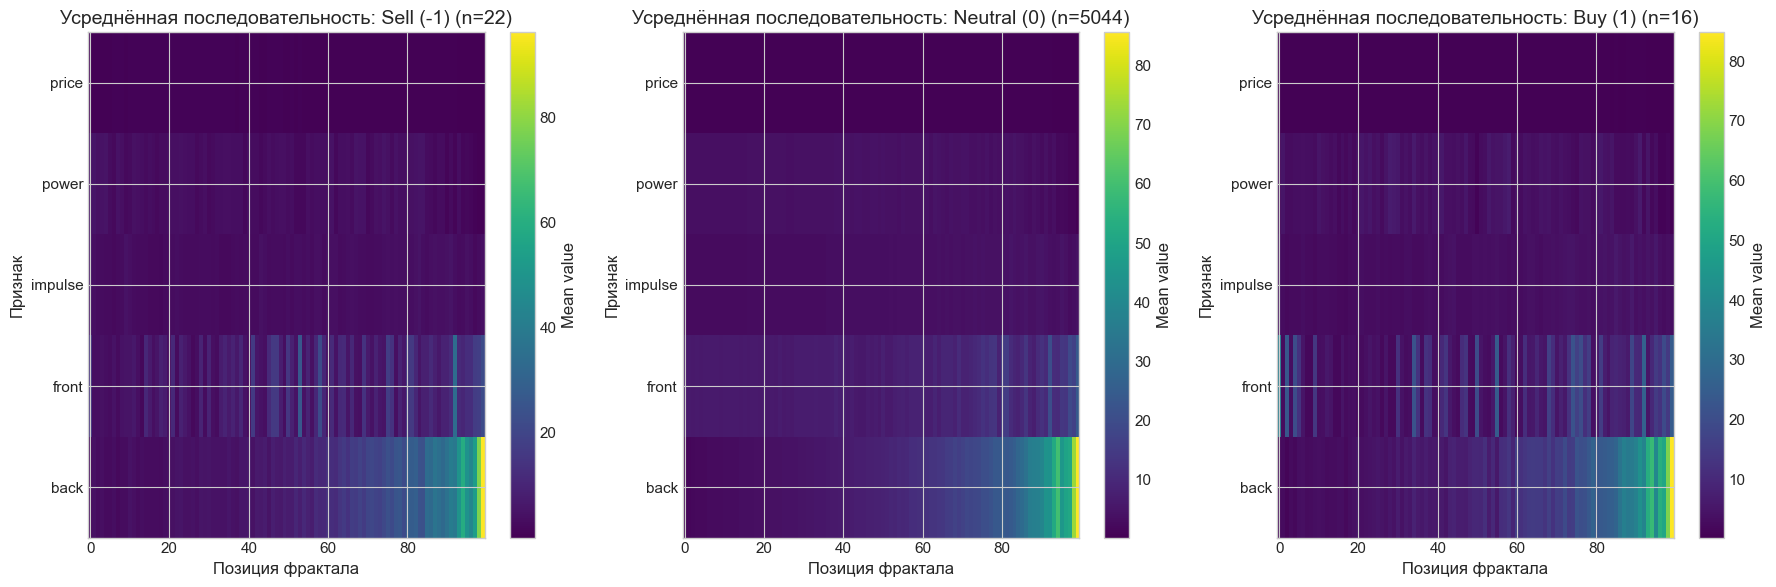

✅ График сохранён: plots/sequence_heatmaps_by_class.png


In [34]:
print("=" * 60)
print("9.4 ВИЗУАЛИЗАЦИЯ ПАТТЕРНОВ ПОСЛЕДОВАТЕЛЬНОСТИ")
print("=" * 60)

# Sequence heatmaps по классам
print("\n1. Sequence heatmaps по классам...")

# Усреднение последовательностей по классам
feature_idx_map = {
    'price': 1,
    'direction': 2,
    'front': 3,
    'back': 4,
    'power': 8,
    'impulse': 10
}

key_features = ['price', 'power', 'impulse', 'front', 'back']
key_feat_indices = [feature_idx_map[f] for f in key_features]

classes_for_heatmap = sorted(set(y_full[valid_mask].astype(int).tolist()))
n_classes_heatmap = len(classes_for_heatmap)
fig, axes = plt.subplots(1, max(n_classes_heatmap, 1), figsize=(6*max(n_classes_heatmap, 1), 6))
if n_classes_heatmap == 1:
    axes = [axes]  # Ensure axes is iterable

for class_idx, class_val in enumerate(classes_for_heatmap):
    mask = (y_full == class_val) & valid_mask
    if mask.sum() == 0:
        continue
    
    class_data = X_full[mask]  # (n_samples, n_fractals, 11)
    
    # Усредняем по всем последовательностям класса
    mean_seq = np.nanmean(class_data, axis=0)  # (n_fractals, 11)
    
    # Берём только ключевые признаки
    mean_seq_key = mean_seq[:, key_feat_indices]  # (n_fractals, 5)
    
    # Heatmap
    im = axes[class_idx].imshow(mean_seq_key.T, aspect='auto', cmap='viridis', 
                               interpolation='nearest')
    axes[class_idx].set_xlabel('Позиция фрактала')
    axes[class_idx].set_ylabel('Признак')
    axes[class_idx].set_yticks(range(len(key_features)))
    axes[class_idx].set_yticklabels(key_features)
    axes[class_idx].set_title(f'Усреднённая последовательность: {CLASS_NAMES.get(class_val, f"Class {class_val}")} (n={mask.sum()})')
    plt.colorbar(im, ax=axes[class_idx], label='Mean value')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}sequence_heatmaps_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ График сохранён: {PLOTS_DIR}sequence_heatmaps_by_class.png")


2. Sample sequences visualization...


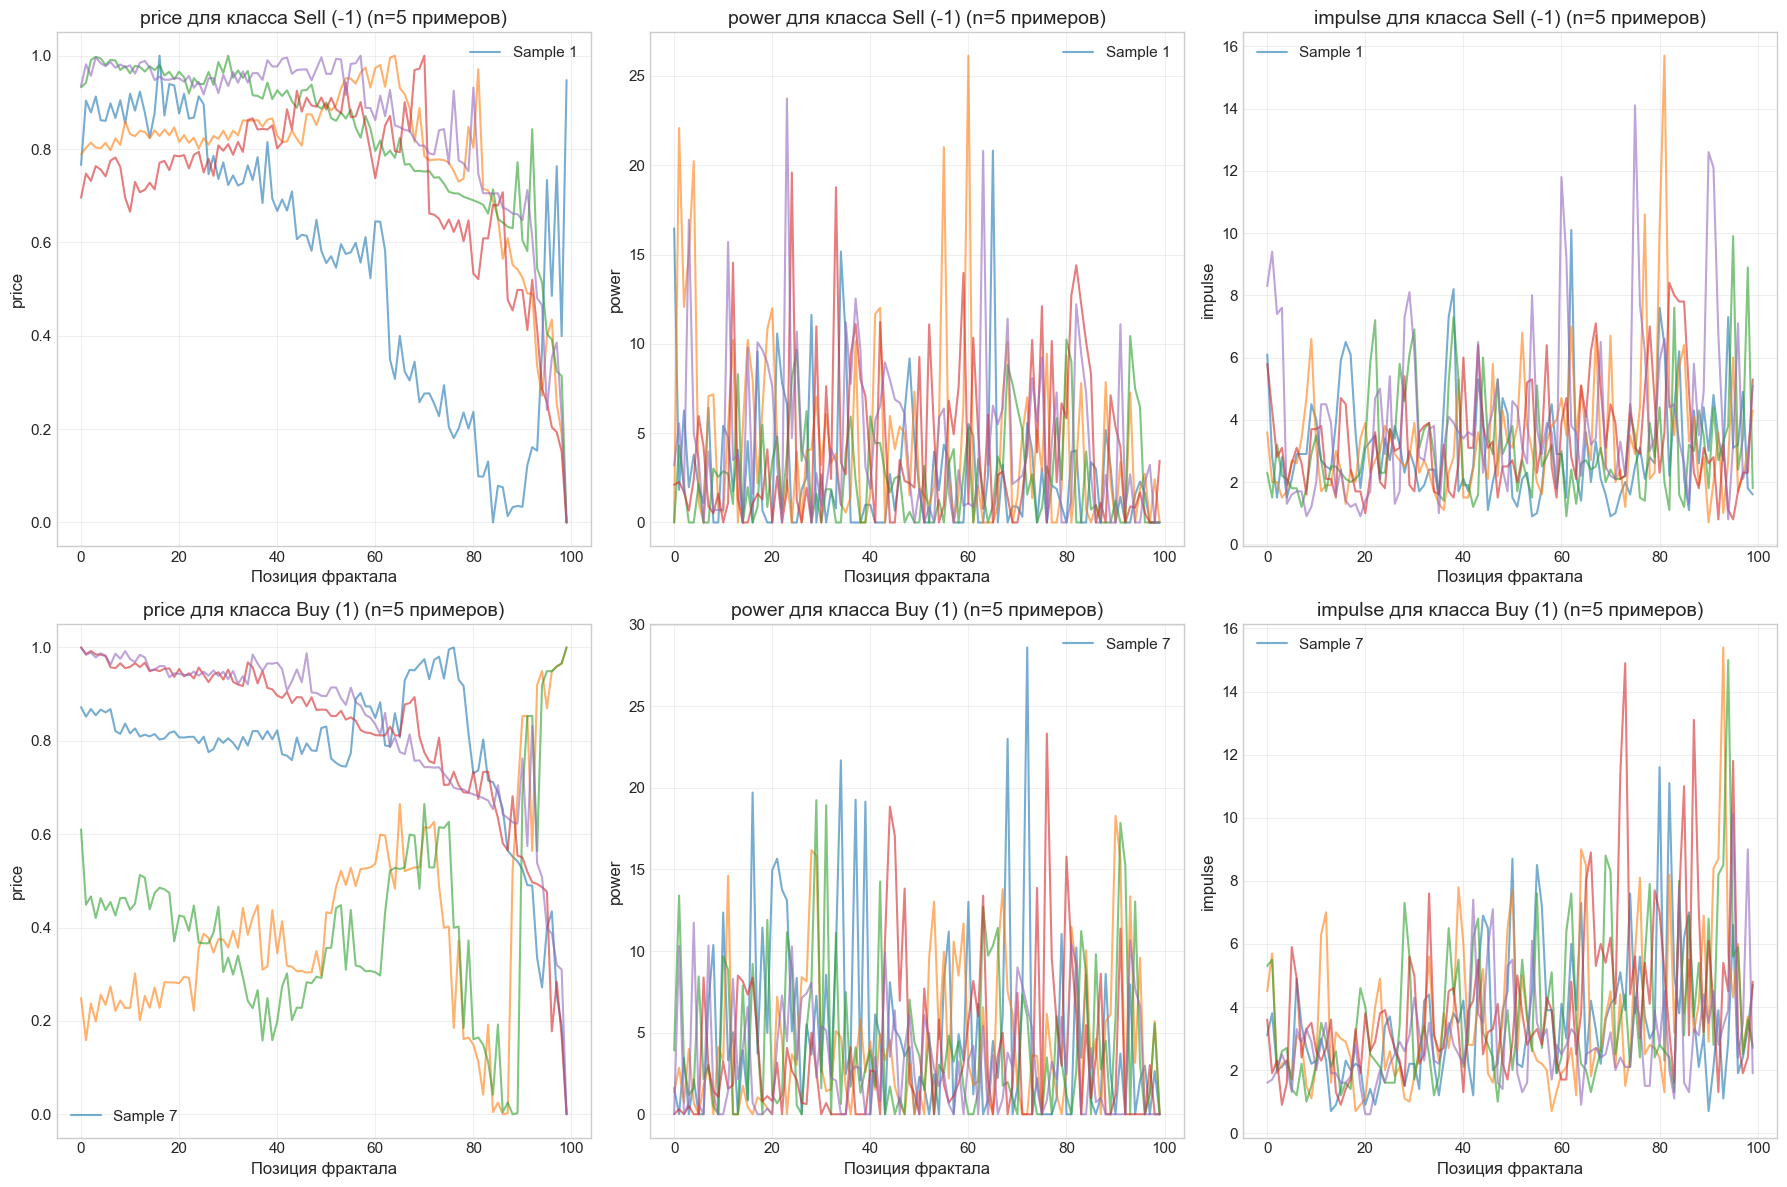

✅ График сохранён: plots/sample_sequences_minority_classes.png


In [35]:
# Sample sequences visualization для minority классов
print("\n2. Sample sequences visualization...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for class_idx, class_val in enumerate([-1, 1]):
    mask = (y_full == class_val) & valid_mask
    if mask.sum() == 0:
        continue
    
    class_data = X_full[mask]
    class_indices = np.where(mask)[0]
    
    # Выбираем 3-5 примеров
    n_samples = min(5, len(class_data))
    sample_indices = np.random.choice(len(class_data), n_samples, replace=False)
    
    # Графики для price, power, impulse
    for feat_idx, feat_name in enumerate(['price', 'power', 'impulse']):
        ax = axes[class_idx * 3 + feat_idx]
        
        for sample_idx in sample_indices:
            seq = class_data[sample_idx, :, feature_idx_map[feat_name]]
            valid_mask_seq = ~np.isnan(seq)
            positions = np.arange(len(seq))[valid_mask_seq]
            values = seq[valid_mask_seq]
            
            ax.plot(positions, values, alpha=0.6, linewidth=1.5, 
                   label=f'Sample {sample_idx}' if sample_idx == sample_indices[0] else '')
        
        ax.set_xlabel('Позиция фрактала')
        ax.set_ylabel(feat_name)
        ax.set_title(f'{feat_name} для класса {CLASS_NAMES.get(class_val, f"Class {class_val}")} (n={n_samples} примеров)')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}sample_sequences_minority_classes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ График сохранён: {PLOTS_DIR}sample_sequences_minority_classes.png")


3. Differential patterns...


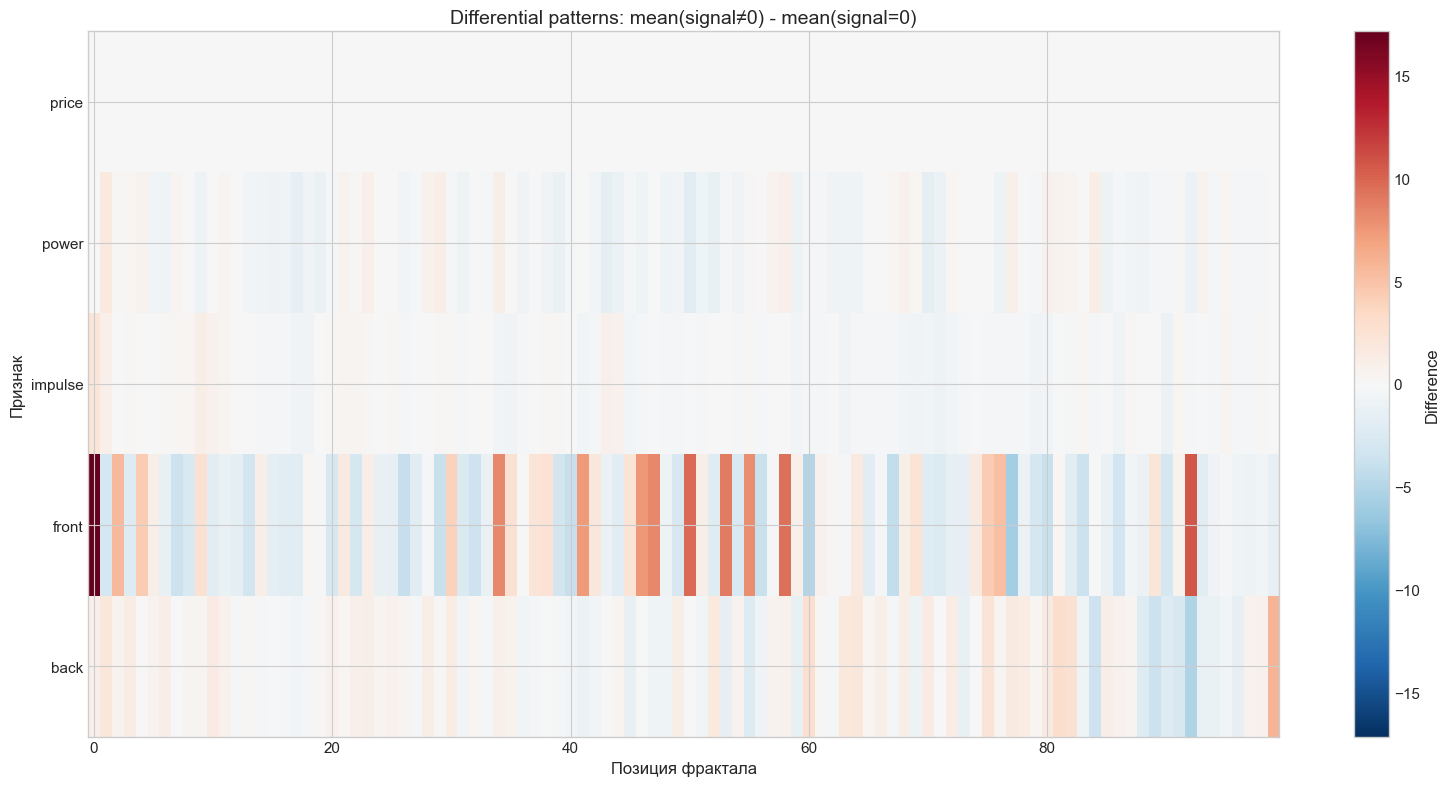

✅ График сохранён: plots/differential_patterns.png


In [36]:
# Differential patterns (signal≠0 vs signal=0)
print("\n3. Differential patterns...")

# Для каждой позиции и каждого признака вычисляем разницу
class_0_mask = (y_full == 0) & valid_mask
class_0_data = X_full[class_0_mask]

minority_mask = ((y_full == -1) | (y_full == 1)) & valid_mask
minority_data = X_full[minority_mask]

# Вычисляем разницу mean
diff_matrix = np.full((n_fractals, 11), np.nan)

for pos in range(n_fractals):
    for feat_idx in range(11):
        class_0_values = class_0_data[:, pos, feat_idx]
        minority_values = minority_data[:, pos, feat_idx]
        
        class_0_clean = class_0_values[~np.isnan(class_0_values)]
        minority_clean = minority_values[~np.isnan(minority_values)]
        
        if len(class_0_clean) > 10 and len(minority_clean) > 10:
            diff = np.mean(minority_clean) - np.mean(class_0_clean)
            diff_matrix[pos, feat_idx] = diff

# Heatmap различий
fig, ax = plt.subplots(figsize=(16, 8))

key_feat_indices = [feature_idx_map[f] for f in key_features]
diff_matrix_key = diff_matrix[:, key_feat_indices]

im = ax.imshow(diff_matrix_key.T, aspect='auto', cmap='RdBu_r', 
              interpolation='nearest', vmin=-np.nanmax(np.abs(diff_matrix_key)), 
              vmax=np.nanmax(np.abs(diff_matrix_key)))
ax.set_xlabel('Позиция фрактала')
ax.set_ylabel('Признак')
ax.set_yticks(range(len(key_features)))
ax.set_yticklabels(key_features)
ax.set_title('Differential patterns: mean(signal≠0) - mean(signal=0)')
plt.colorbar(im, ax=ax, label='Difference')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}differential_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ График сохранён: {PLOTS_DIR}differential_patterns.png")

Раздел 9.5: Корреляционный анализ engineered features

In [37]:
print("=" * 60)
print("9.5 КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ENGINEERED FEATURES")
print("=" * 60)

from sklearn.feature_selection import mutual_info_classif
from scipy.stats import pointbiserialr

# Подготовка данных
feature_cols = [col for col in engineered_features.columns if col not in ['signal', 'row_idx']]
X_features = engineered_features[feature_cols].fillna(0)  # Заполняем NaN нулями
y_target = engineered_features['signal']

print(f"\nАнализ {len(feature_cols)} признаков...")

# 1. Feature importance ranking
print("\n1. Feature importance ranking...")

# Correlation с целевой переменной
correlations = []
for col in feature_cols:
    try:
        corr, p_value = pointbiserialr(X_features[col], y_target)
        correlations.append({
            'feature': col,
            'correlation': corr if not np.isnan(corr) else 0,
            'p_value': p_value if not np.isnan(p_value) else 1
        })
    except:
        correlations.append({
            'feature': col,
            'correlation': 0,
            'p_value': 1
        })

corr_df = pd.DataFrame(correlations)
corr_df['abs_correlation'] = np.abs(corr_df['correlation'])
corr_df = corr_df.sort_values('abs_correlation', ascending=False)

# Mutual Information (выборочно для топ-100 по корреляции, т.к. это медленно)
print("   Вычисление Mutual Information для топ-100 признаков...")
top_100_features = corr_df.head(100)['feature'].values
X_top100 = X_features[top_100_features]

try:
    mi_scores = mutual_info_classif(X_top100, y_target, random_state=42, n_neighbors=3)
    mi_dict = dict(zip(top_100_features, mi_scores))
    
    # Добавляем MI в DataFrame
    corr_df['mutual_info'] = corr_df['feature'].map(mi_dict).fillna(0)
except Exception as e:
    print(f"   ⚠️ Ошибка при вычислении MI: {e}")
    corr_df['mutual_info'] = 0

# Финальный ranking
corr_df['importance_score'] = (corr_df['abs_correlation'] * 0.5 + 
                                corr_df['mutual_info'] / corr_df['mutual_info'].max() * 0.5)
corr_df = corr_df.sort_values('importance_score', ascending=False)

print(f"\n   Топ-20 признаков по важности:")
print(corr_df.head(20)[['feature', 'correlation', 'mutual_info', 'importance_score']].to_string())

# Сохранение ranking
corr_df.to_csv(f'{PLOTS_DIR}feature_importance_sequence.csv', index=False)
print(f"\n✅ Feature importance сохранён: {PLOTS_DIR}feature_importance_sequence.csv")

9.5 КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ENGINEERED FEATURES

Анализ 233 признаков...

1. Feature importance ranking...


   Вычисление Mutual Information для топ-100 признаков...



   Топ-20 признаков по важности:
                  feature  correlation  mutual_info  importance_score
203      price_zscore_w20     0.134986     0.012233          0.552806
204  price_percentile_w20     0.111818     0.012125          0.536949
200  price_percentile_w10     0.115491     0.011635          0.519325
7            front_max_w1     0.033973     0.012603          0.516987
6            front_min_w1     0.033973     0.012603          0.516987
4           front_mean_w1     0.033973     0.012603          0.516987
199      price_zscore_w10     0.131226     0.010881          0.497294
171         price_slope_3    -0.125659     0.008304          0.392285
174         price_slope_4    -0.113163     0.007235          0.343624
31           front_max_w2     0.029209     0.008263          0.342405
55           front_max_w3     0.028721     0.007529          0.313051
168         price_slope_2    -0.134867     0.006066          0.308097
35            back_max_w2    -0.062185     0.006613     

In [38]:
# 2. Redundancy analysis
print("\n2. Redundancy analysis...")

# Корреляционная матрица всех признаков (выборочно для топ-50)
top_50_features = corr_df.head(50)['feature'].values
X_top50 = X_features[top_50_features]

corr_matrix = X_top50.corr().abs()

# Находим пары с correlation > 0.95
redundant_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if corr_val > 0.95:
            redundant_pairs.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_val
            })

if redundant_pairs:
    redundant_df = pd.DataFrame(redundant_pairs)
    print(f"   Найдено {len(redundant_pairs)} пар с correlation > 0.95:")
    print(redundant_df.head(10).to_string())
    
    # Рекомендации: какие признаки можно удалить
    features_to_remove = set()
    for _, row in redundant_df.iterrows():
        feat1_importance = corr_df[corr_df['feature'] == row['feature1']]['importance_score'].values[0]
        feat2_importance = corr_df[corr_df['feature'] == row['feature2']]['importance_score'].values[0]
        
        if feat1_importance < feat2_importance:
            features_to_remove.add(row['feature1'])
        else:
            features_to_remove.add(row['feature2'])
    
    print(f"\n   Рекомендация: можно удалить {len(features_to_remove)} признаков:")
    print(f"   {list(features_to_remove)[:10]}")
else:
    print("   ✅ Redundant features не обнаружено (correlation < 0.95)")


2. Redundancy analysis...
   Найдено 16 пар с correlation > 0.95:
               feature1              feature2  correlation
0      price_zscore_w20  price_percentile_w20     0.957876
1  price_percentile_w10      price_zscore_w10     0.953528
2          front_max_w1          front_min_w1     1.000000
3          front_max_w1         front_mean_w1     1.000000
4          front_min_w1         front_mean_w1     1.000000
5          front_max_w2          front_std_w2     0.965944
6          front_max_w3          front_std_w3     0.999470
7           back_max_w2          back_mean_w2     0.962864
8          front_std_w4          front_max_w4     0.997204
9       impulse_mean_w1        impulse_max_w1     1.000000

   Рекомендация: можно удалить 13 признаков:
   ['back_mean_w2', 'front_mean_w1', 'price_zscore_w10', 'front_min_w1', 'front_max_w4', 'impulse_min_w1', 'impulse_max_w1', 'front_max_w5', 'front_std_w3', 'back_max_w1']



3. Feature stability по классам...


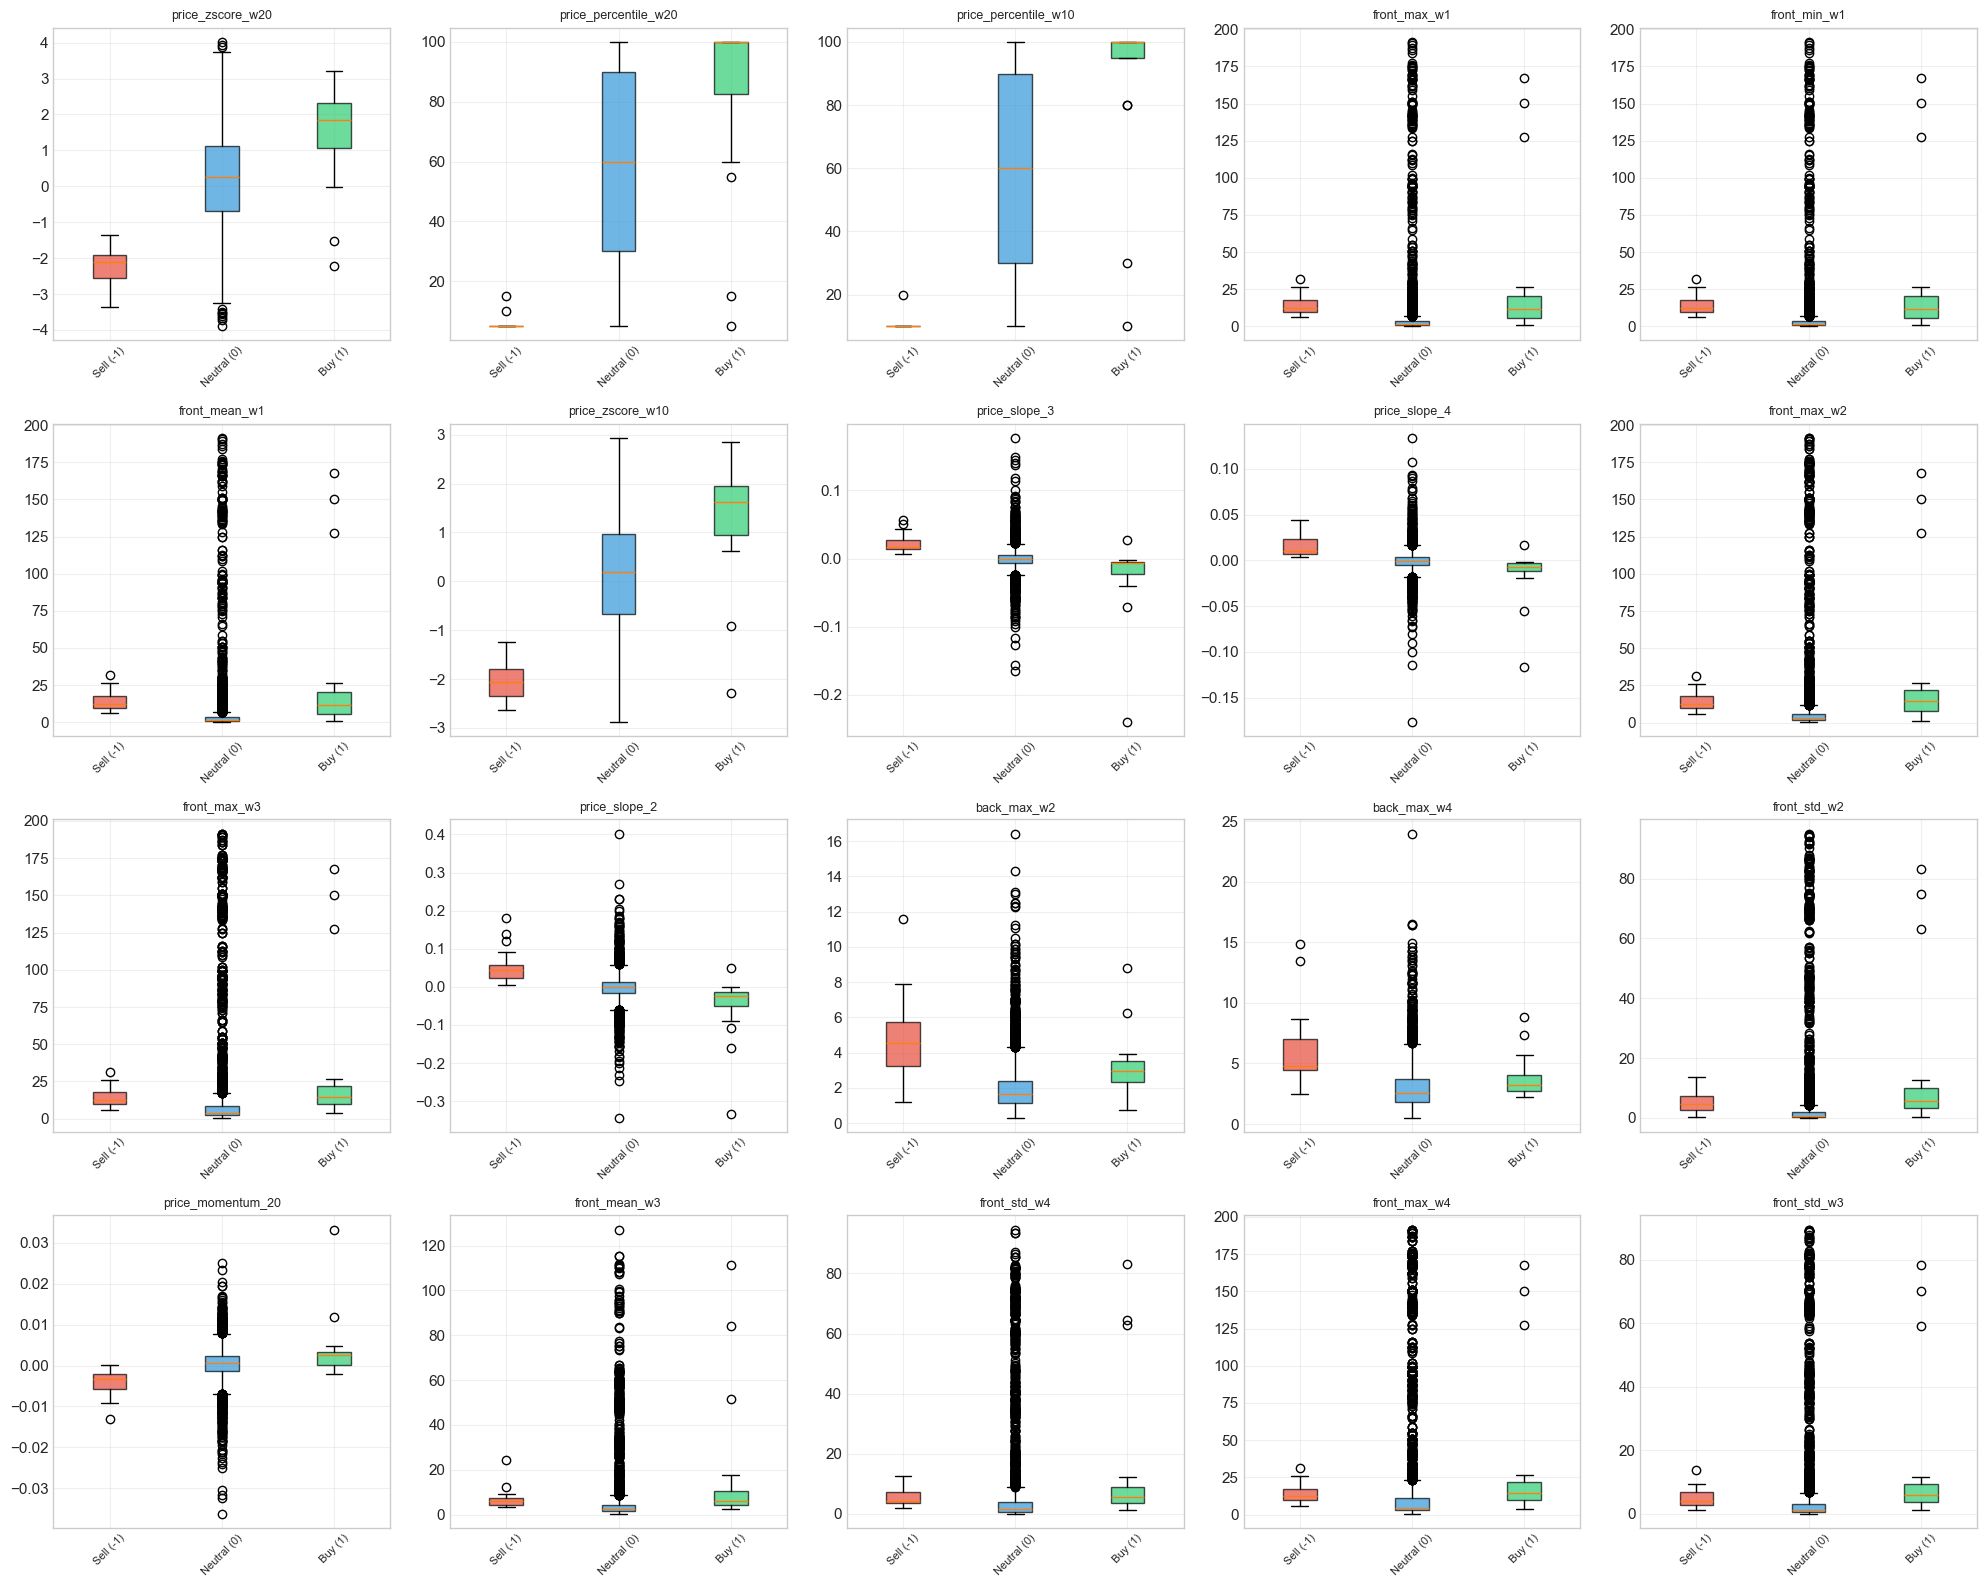

✅ График сохранён: plots/engineered_features_boxplots.png


In [39]:
# 3. Feature stability по классам
print("\n3. Feature stability по классам...")

# Boxplot для топ-20 признаков
top_20_features = corr_df.head(20)['feature'].values

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for idx, feat_name in enumerate(top_20_features[:20]):
    ax = axes[idx]
    
    data_by_class = []
    labels = []
    
    available_signals_feat = sorted(y_target.unique())
    for class_val in available_signals_feat:
        mask = y_target == class_val
        values = X_features.loc[mask, feat_name]
        values_clean = values[~np.isnan(values)]
        
        if len(values_clean) > 0:
            data_by_class.append(values_clean)
            labels.append(CLASS_NAMES.get(class_val, f'Class {class_val}'))
    
    if data_by_class:
        bp = ax.boxplot(data_by_class, labels=labels, patch_artist=True)
        
        # Раскрашиваем boxplots
        colors_feat = [CLASS_COLORS.get(c, '#808080') for c in available_signals_feat[:len(bp['boxes'])]]
        for patch, color in zip(bp['boxes'], colors_feat):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_title(feat_name[:30], fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}engineered_features_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ График сохранён: {PLOTS_DIR}engineered_features_boxplots.png")

Раздел 9.6: Экспорт результатов

In [40]:
print("=" * 60)
print("9.6 ЭКСПОРТ РЕЗУЛЬТАТОВ")
print("=" * 60)

import json
from datetime import datetime

# 1. Сохранение engineered dataset
print("\n1. Сохранение engineered dataset...")

# Добавляем временные признаки из исходных данных
if 'time' in raw_df.columns:
    engineered_features['time'] = raw_df['time'].values

# Сохранение
output_file = 'nero_features_engineered.csv'
engineered_features.to_csv(output_file, index=False)
print(f"   ✅ Сохранено: {output_file}")
print(f"   Размерность: {engineered_features.shape}")

9.6 ЭКСПОРТ РЕЗУЛЬТАТОВ

1. Сохранение engineered dataset...


   ✅ Сохранено: nero_features_engineered.csv
   Размерность: (5082, 236)


In [41]:
# 2. Feature catalog (JSON)
print("\n2. Создание feature catalog...")

feature_catalog = []

for idx, row in corr_df.iterrows():
    feat_name = row['feature']
    
    # Определяем тип признака
    feat_type = 'unknown'
    window = None
    base_feature = None
    aggregation = None
    
    if '_mean_w' in feat_name:
        feat_type = 'rolling_statistic'
        parts = feat_name.split('_mean_w')
        base_feature = parts[0]
        window = int(parts[1])
        aggregation = 'mean'
    elif '_std_w' in feat_name:
        feat_type = 'rolling_statistic'
        parts = feat_name.split('_std_w')
        base_feature = parts[0]
        window = int(parts[1])
        aggregation = 'std'
    elif '_slope_' in feat_name:
        feat_type = 'trend_indicator'
        parts = feat_name.split('_slope_')
        base_feature = parts[0]
        window = int(parts[1])
        aggregation = 'slope'
    elif '_zscore_w' in feat_name:
        feat_type = 'relative_feature'
        parts = feat_name.split('_zscore_w')
        base_feature = parts[0]
        window = int(parts[1])
        aggregation = 'zscore'
    elif 'interaction' in feat_name:
        feat_type = 'interaction_feature'
    elif 'momentum' in feat_name or 'volatility' in feat_name:
        feat_type = 'momentum_volatility'
    elif 'direction' in feat_name:
        feat_type = 'directional_pattern'
    elif 'time' in feat_name:
        feat_type = 'time_based'
    else:
        feat_type = 'other'
    
    feature_catalog.append({
        'feature_name': feat_name,
        'type': feat_type,
        'window': window,
        'base_feature': base_feature,
        'aggregation': aggregation,
        'importance_rank': int(row.name) + 1,
        'correlation_with_target': float(row['correlation']),
        'mutual_information': float(row['mutual_info']),
        'importance_score': float(row['importance_score'])
    })

# Сохранение
with open('feature_catalog.json', 'w', encoding='utf-8') as f:
    json.dump(feature_catalog, f, indent=2, ensure_ascii=False)

print(f"   ✅ Сохранено: feature_catalog.json")
print(f"   Записей: {len(feature_catalog)}")


2. Создание feature catalog...
   ✅ Сохранено: feature_catalog.json
   Записей: 233


In [42]:
# 3. Отчёт с рекомендациями (Markdown)
print("\n3. Создание отчёта...")

report = f"""# Sequence Analysis Summary

**Дата создания:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Data Quality

- **Successfully parsed:** {parse_stats['valid_rows']} строк ({parse_stats['parse_rate']:.2f}%)
- **Missing values:** {'Обнаружены' if missing_rate_per_position.max() > 0 else 'Не обнаружены'}
- **Causal consistency:** {'⚠️ ISSUES DETECTED' if len(causal_violations) > 0 else '✅ PASSED'}
  - Нарушения порядка: {len(causal_violations) if 'causal_violations' in locals() else 0} строк
  

## Key Findings

### Топ-10 наиболее дискриминативных позиций фракталов:

"""

# Добавляем информацию о топ позициях
if 'cohens_d_results' in locals():
    for minority_class in [-1, 1]:
        if minority_class in cohens_d_results:
            matrix = np.abs(cohens_d_results[minority_class])
            pos_scores = np.nanmean(matrix, axis=1)
            top_positions = np.argsort(pos_scores)[-10:][::-1]
            report += f"\n**Класс {minority_class}:**\n"
            for pos in top_positions[:10]:
                report += f"- Позиция {pos}: средний |Cohen's d| = {pos_scores[pos]:.3f}\n"

report += f"""

### Топ-20 engineered features по важности:

"""

# Добавляем топ-20 признаков
for idx, row in corr_df.head(20).iterrows():
    report += f"{idx+1}. **{row['feature']}** (correlation={row['correlation']:.3f}, MI={row['mutual_info']:.3f})\n"

report += f"""

## Recommendations for Modeling

### 1. Архитектура модели

- **Вариант A:** Использовать full sequence ({n_fractals} фракталов) с LSTM/Transformer
  - Преимущества: сохранение временной структуры
  - Недостатки: требует больше вычислительных ресурсов
  
- **Вариант B:** Feature-based модель с engineered features ({len(feature_cols)} признаков)
  - Преимущества: быстрее обучение, интерпретируемость
  - Недостатки: потеря части временной информации

### 2. Критичные признаки

Топ-10 признаков для включения в модель:
"""

for idx, row in corr_df.head(10).iterrows():
    report += f"- `{row['feature']}` (importance={row['importance_score']:.4f})\n"

report += f"""

### 3. Temporal features

Рекомендуется добавить:
- `hour_sin`, `hour_cos` (из времени)
- `day_of_week_sin`, `day_of_week_cos` (из времени)

### 4. Data Leakage Check

**Status:** {'❌ ISSUES DETECTED' if ('causal_violations' in locals() and len(causal_violations) > 0) else '✅ PASSED'}

**Details:**

- Требуется дополнительный анализ: возможно, это особенность структуры данных
- Рекомендуется проверить логику формирования фракталов

### 5. Feature Selection

- Всего создано: {len(feature_cols)} признаков
- Redundant features (correlation > 0.95): {len(redundant_pairs) if 'redundant_pairs' in locals() else 0}
- Рекомендуется удалить избыточные признаки перед обучением

## Файлы результатов

- `nero_features_engineered.csv` - датасет с engineered features
- `feature_catalog.json` - метаданные признаков
- `feature_importance_sequence.csv` - ranking признаков
- `sequence_heatmaps_by_class.png` - heatmaps по классам
- `sample_sequences_minority_classes.png` - примеры последовательностей
- `differential_patterns.png` - дифференциальные паттерны
- `engineered_features_boxplots.png` - boxplots признаков

---

**Следующие шаги:**
2. Выбрать архитектуру модели (LSTM/Transformer vs Feature-based)
3. Подготовить train/test split с учётом временной структуры
4. Применить техники балансировки классов (SMOTE, class weights)
5. Обучить модель и оценить на тестовой выборке
"""

# Сохранение отчёта
with open('sequence_analysis_report.md', 'w', encoding='utf-8') as f:
    f.write(report)

print(f"   ✅ Сохранено: sequence_analysis_report.md")

print("\n" + "=" * 60)
print("✅ ЭКСПОРТ ЗАВЕРШЁН")
print("=" * 60)
print("\nСозданные файлы:")
print("  - nero_features_engineered.csv")
print("  - feature_catalog.json")
print("  - feature_importance_sequence.csv")
print("  - sequence_analysis_report.md")
print("\n✅ Раздел 9 (Анализ полной последовательности фракталов) завершён!")


3. Создание отчёта...
   ✅ Сохранено: sequence_analysis_report.md

✅ ЭКСПОРТ ЗАВЕРШЁН

Созданные файлы:
  - nero_features_engineered.csv
  - feature_catalog.json
  - feature_importance_sequence.csv
  - sequence_analysis_report.md

✅ Раздел 9 (Анализ полной последовательности фракталов) завершён!
